# Purpose and boundaries

The [baseline notebook](microsim_base_ACC_2012_2024.ipynb) built an executable 15–65 annual engine and showed that **one** consumption specification (a per-cell linear logit trend fitted to 2012–2020) predicts 2022/2024 prevalence badly: RMSE 10.26 percentage points, mean overprediction 9.75 points. The Codex review of that result made four points that this notebook addresses with code rather than prose: (1) the failure is a failure of that time-curve specification, not of the microsimulation approach; (2) reconstruction of 2012–2024 and projection after 2024 are different objectives with different evidence; (3) projection rules must be compared by successive temporal cutoffs, not by one holdout; (4) survey comparability across waves, and the 2020 wave in particular, need an explicit audit and sensitivity, not silent exclusion.

**What is reused unchanged:** survey inputs and design targets, INE/HMD/DEIS inputs, the annual person-level engine, the Gaussian persistence assumption, all-cause mortality scaling and the engineering checks. Those cells are copied verbatim from the baseline so that results differ only because of what is new.

**What is new:** `ms_fit()` takes a `spec` argument selecting the prevalence/intensity time curve (static 2012; wave interpolation with last value carried forward; per-cell linear trend; cell intercepts with a shared natural spline) and a `drop_2020` switch. A per-wave comparability audit, a rolling-origin evaluation (fit through 2016 → predict 2018; through 2018 → 2020; through 2020 → 2022; through 2022 → 2024, at one- and two-wave horizons), a 2020 sensitivity, a seven-wave reconstruction run with Monte Carlo replication, and a 2025–2034 projection under three explicit rules. Seeds are 2125–2129.

**Boundaries that do not change:** repeated cross-sections identify marginal distributions, not individual transitions; reproducing calibration targets is fitting, not validation; mortality remains independent of alcohol exposure; once 2022/2024 inform model choice they are development data, and the temporal cutoffs reported here are the honest replacement for a single untouched holdout. No second engine (`data.table` or `MicSim`) is added: the baseline audit and the Codex review agree that engine equivalence cannot fix a misspecified consumption curve.

**Observed execution result (seeds 2125–2129, 25,000 people):** all code cells complete in about one minute and every engineering check passes. No projection rule dominates the rolling-origin comparison: one wave ahead, the shared spline averages 4.5 percentage points RMSE, hold-last 4.9, static-2012 5.4 and the per-cell linear trend 6.7; two waves ahead, static-2012 is best (5.9). Only the shared spline partly anticipates the 2022 decline from data through 2020 (3.3 points), and that result disappears when the 2020 wave is dropped (6.3 points). The seven-wave reconstruction reproduces prevalence to 0.5 points (Monte Carlo SD 0.9) and intensity to 0.11 g/day; HED remains underpredicted by 4.5 points because it is not calibrated. “The 2022 wave has a distinct weighting profile (weight CV 1.05 versus 1.6–1.9; implied population 91% of INE versus 77–80%), alongside documented changes in the sampling frame and weight calibration, including calibration to full regional urban population totals.


## 1. Codex concerns and their implementation

| Codex concern | What it implies | Implementation here |
| :--- | :--- | :--- |
| “La validación falla” applied only to the linear-trend prevalence prediction; code checks passed and intensity was acceptable | Report the three evaluations separately: code verification, historical fit, temporal prediction | Checks (Section 8), reconstruction fit (Section 11), rolling-origin prediction (Section 9) are separate tables with separate captions |
| Separate reconstruction 2012–2024 from projection after 2024 | Reconstruction may use all seven waves; projection needs a rule chosen on evidence about extrapolation | `interp_hold` reproduces wave targets by interpolation; projection rules are compared on successive cutoffs before any is used for 2025–2034 |
| Evaluate projection rules by successive temporal cutoffs | Fit ≤2016 → 2018, ≤2018 → 2020, ≤2020 → 2022, ≤2022 → 2024; compare hold-last, trend and a moderately flexible curve | `ms_rolling` at the driver level (deterministic), then a microsimulation confirmation for the 2020 cutoff with five seeds |
| Audit survey comparability; treat 2020 by sensitivity, do not exclude it because it worsens fit | Quantify what the files allow; name what they do not | Per-wave audit of missingness, weights, coverage against INE and age/sex composition; all cutoff analyses repeated with 2020 dropped |
| RMSE is an unweighted cell RMSE in percentage points | Keep units explicit | Probability metrics reported in proportion units and labelled in percentage points in the text |
| rho is not the knob for a wrong marginal trend | Keep persistence sensitivity separate from time-curve choice | Section 13 repeats the sensitivity with the reconstruction model; no rho tuning |
| data.table / MicSim engines were never run | Do not present engine equivalence as validation | Not added; recorded as deferred with the reason |

Not addressed here because the data are not in the project: longitudinal panels, retrospective drinking history, independent comparable surveys, beverage-specific sales/APC bridges and the cause-specific mortality link. Section 17 lists them with what each would allow.


## 2. Reference architecture

Unchanged from the baseline: [@kilian2025targeting]; SIMAH release 0.1.1, cited by DOI and not vendored in this repository [@probst2025simah]. The schedule (record → mortality → age/exit → reconcile stocks → next-year exposure at attained age), entity definitions and stochastic components are those documented in the baseline, Section 2. The only architectural change is that the exposure drivers now depend on a declared time-curve specification.


## 3. Configuration and outputs

25,000 synthetic people, five Monte Carlo seeds (2125–2129) for replicated runs, persistence 0.8 as a working structural assumption. Cutoffs 2016–2022 and four specifications are asserted in the configuration. Outputs go to a separate directory so that the baseline exports remain untouched.


In [2]:
#| label: ms-setup
#| results: "hold"
.t0 <- Sys.time()
ms_packages <- base::c("here", "haven", "survey", "dplyr", "readxl", "arrow", "knitr", "IRdisplay", "ggplot2", "splines", "tidyr")
ms_missing <- ms_packages[!base::vapply(ms_packages, base::requireNamespace, base::logical(1), quietly = TRUE)]
if (base::length(ms_missing)) base::stop("Missing packages: ", base::paste(ms_missing, collapse = ", "))
base::suppressMessages(here::i_am("__andres_control/microsim_recalib_ACC_2012_2024.ipynb"))
source(here::here("_tools", "acc_data.R"))
ms_cfg <- base::list(start_year = 2012L, train_end = 2020L, observed_end = 2024L, end_year = 2034L,
  min_age = 15L, max_age = 65L, n_sim = 25000L, seeds = 2125L + 0:4, rho = 0.8,
  cutoffs = base::c(2016L, 2018L, 2020L, 2022L),
  specs = base::c("static2012", "interp_hold", "linear_all", "spline_shared"),
  export = TRUE, output_dir = "__andres_control/microsim_recalib_outputs")
base::stopifnot(ms_cfg$min_age == 15L, ms_cfg$max_age == 65L, ms_cfg$start_year == 2012L,
  ms_cfg$train_end == 2020L, ms_cfg$observed_end == 2024L, ms_cfg$end_year == 2034L,
  base::length(ms_cfg$seeds) >= 2L, ms_cfg$seeds[1] == 2125L)
# 2026-10-09: add a guard to the function to work
ms_table <- function(x, caption = NULL) {
  tab <- knitr::kable(x, format = if (isTRUE(getOption("jupyter.in_kernel"))) "html" else "pipe",
    digits = 4, row.names = FALSE, caption = caption)
  if (isTRUE(getOption("jupyter.in_kernel"))) IRdisplay::display_html(base::as.character(tab)) else base::print(tab)
}
base::message(base::sprintf("ms-setup elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


ms-setup elapsed minutes: 0.03


## 4. Survey inputs and design targets (verbatim from the baseline)

Seven repeated cross-sections with IDs and exact ages, joined to design weights; past-30-day current drinking, survey-scale g/day with the 12-g convention, HED among current drinkers; working design-based standard errors (2020 weights-only). See the baseline, Section 4, for the measurement caveats. The code is copied unchanged so that `ms_targets` is identical.


In [3]:
#| label: ms-survey-inputs
#| results: "hold"
.t0 <- Sys.time()
# Keep IDs and exact ages; the saved PIF exposure cache discards both.
# Resolve a label to a readable path: "bundle.tar.xz.enc::member" or "bundle.tar.xz.enc" -> decrypted file (acc_data()); anything else -> repo-relative path.
ms_path <- function(label) base::vapply(label, function(z) {
  if (base::grepl("::", z, fixed = TRUE)) {
    p <- base::strsplit(z, "::", fixed = TRUE)[[1L]]
    acc_data(p[[1L]], p[[2L]])
  } else if (base::grepl("\\.tar\\.xz\\.enc$", z)) {
    acc_data(z)
  } else {
    here::here(z)
  }
}, base::character(1), USE.NAMES = FALSE)
ms_exposure_files <- base::c(
  binge = "_enpg/enpg.tar.xz.enc::derived/ENPG_BINGE.RDS",
  design = "_enpg/enpg.tar.xz.enc::derived/enpg_design_waves_2012_2024_list.RDS",
  psu2016 = "_enpg/enpg.tar.xz.enc::base ENPG 2016 publico general.dta")
base::stopifnot(base::all(base::file.exists(ms_path(ms_exposure_files))),
  base::all(base::file.info(ms_path(ms_exposure_files))$size > 2))
ms_exposure_provenance <- base::data.frame(input = base::names(ms_exposure_files),
  file = base::unname(ms_exposure_files), bytes = base::file.info(ms_path(ms_exposure_files))$size,
  md5 = base::unname(tools::md5sum(ms_path(ms_exposure_files))))
ms_raw <- base::readRDS(ms_path(ms_exposure_files[["binge"]]))
ms_design_cache <- base::readRDS(ms_path(ms_exposure_files[["design"]]))
ms_wave_years <- base::seq(2012L, 2024L, 2L)
base::stopifnot(base::all(base::c("id", "year", "sexo", "edad", "exp", "oh1", "oh2", "oh3", "db", "audit2") %in% base::names(ms_raw)),
  base::setequal(ms_raw$year, ms_wave_years),
  base::setequal(base::names(ms_design_cache$waves), base::as.character(ms_wave_years)),
  !base::anyDuplicated(ms_raw[base::c("year", "id")]))
# The short 2016 key merges distinct blocks; retain district and zone as well.
ms_psu16 <- base::as.data.frame(haven::read_dta(ms_path(ms_exposure_files[["psu2016"]]),
  col_select = base::c("idencuesta", "comuna", "distrito", "zona", "manzana")))
base::stopifnot(!base::anyDuplicated(ms_psu16$idencuesta), base::all(stats::complete.cases(ms_psu16)))
ms_design_lookup <- base::do.call(base::rbind, base::lapply(ms_wave_years, function(ms_y) {
  ms_d <- ms_design_cache$waves[[base::as.character(ms_y)]]
  base::stopifnot(base::all(base::c("year", "id_join", "weight", "region", "commune", "psu") %in% base::names(ms_d)),
    !base::anyDuplicated(ms_d$id_join))
  ms_psu <- if (ms_y == 2020L) base::rep(NA_character_, base::nrow(ms_d)) else
    base::paste(ms_d$commune, ms_d$psu, sep = "|")
  if (ms_y == 2016L) {
    ms_j <- base::match(ms_d$id_join, base::as.character(ms_psu16$idencuesta))
    base::stopifnot(!base::anyNA(ms_j))
    ms_psu <- base::do.call(base::paste, base::c(ms_psu16[ms_j,
      base::c("comuna", "distrito", "zona", "manzana")], sep = "|"))
  }
  if (ms_y != 2020L) base::stopifnot(!base::anyNA(ms_d$psu))
  if (ms_y == 2024L) base::stopifnot("ESTRATO" %in% base::names(ms_d))
  base::data.frame(year = ms_y, id = ms_d$id_join, weight = ms_d$weight, psu = ms_psu,
    stratum = base::as.character(if (ms_y == 2024L) ms_d$ESTRATO else ms_d$region),
    design_status = if (ms_y == 2020L) "Weights only; no validated clustering SE" else
      if (ms_y == 2024L) "PSU + supplied ESTRATO" else "PSU + region proxy strata")
}))
base::stopifnot(!base::anyDuplicated(ms_design_lookup[base::c("year", "id")]))
ms_match <- base::match(base::paste(ms_raw$year, ms_raw$id, sep = "|"),
  base::paste(ms_design_lookup$year, ms_design_lookup$id, sep = "|"))
base::stopifnot(!base::anyNA(ms_match))
ms_d <- ms_design_lookup[ms_match, ]
base::stopifnot(base::all(base::is.finite(ms_d$weight) & ms_d$weight > 0),
  !base::anyNA(ms_d$stratum), base::all(ms_raw$sexo %in% base::c("Hombre", "Mujer")),
  base::all(base::is.finite(ms_raw$edad)))
# Use the unrounded public design weight (2014 exp contains rounded weights).
ms_enpg_all <- base::data.frame(id = base::as.character(ms_raw$id), year = base::as.integer(ms_raw$year),
  sex = base::ifelse(ms_raw$sexo == "Hombre", "male", "female"), age = base::as.integer(ms_raw$edad),
  weight = ms_d$weight, psu = ms_d$psu, stratum = ms_d$stratum, design_status = ms_d$design_status)
ms_ever <- base::as.character(ms_raw$oh1)
ms_recency <- base::as.character(ms_raw$oh2)
ms_enpg_all$status <- base::ifelse(ms_ever == "No" & base::is.na(ms_recency), "never",
  base::ifelse(ms_ever == "Si" & ms_recency == "30 dias", "current",
    base::ifelse(ms_ever == "Si" & ms_recency %in% base::c(">30", ">1 a\u00f1o"), "former", NA_character_)))
ms_enpg_all$status[base::is.na(ms_enpg_all$status)] <- "unknown"
ms_enpg_all$current <- base::ifelse(ms_enpg_all$status == "unknown", NA_real_,
  base::as.numeric(ms_enpg_all$status == "current"))
ms_enpg_all$ever <- base::ifelse(ms_ever == "Si", TRUE, base::ifelse(ms_ever == "No", FALSE, NA))
ms_days <- base::as.numeric(ms_raw$oh3)
ms_days[!base::is.finite(ms_days) | ms_days < 0 | ms_days > 30] <- NA_real_
ms_episodes <- base::as.numeric(ms_raw$db)
ms_episodes[!base::is.finite(ms_episodes) | ms_episodes < 0 | ms_episodes >= 88] <- NA_real_
ms_midpoints <- base::c("0-2" = 1, "3-4" = 3.5, "5-6" = 5.5, "7-8" = 7.5, "9 o mas" = 9)
ms_drinks <- base::unname(ms_midpoints[base::as.character(ms_raw$audit2)])
# Inherit the 12-g drink convention; this survey scale has no WHO multiplier.
# Episode counts can exceed drinking days; pmax preserves the existing approximation.
ms_enpg_all$gpd_survey <- (base::pmax(ms_days - ms_episodes, 0) * ms_drinks +
  ms_episodes * base::ifelse(ms_enpg_all$sex == "male", 5, 4)) * 12 / 30
ms_enpg_all$hed <- base::as.numeric(ms_episodes > 0)
ms_noncurrent <- ms_enpg_all$status %in% base::c("never", "former")
ms_enpg_all$gpd_survey[ms_noncurrent] <- 0
ms_enpg_all$hed[ms_noncurrent] <- 0
ms_enpg_all$gpd_survey[ms_enpg_all$status == "unknown"] <- NA_real_
ms_enpg_all$hed[ms_enpg_all$status == "unknown"] <- NA_real_
ms_enpg_all$age_group <- base::findInterval(ms_enpg_all$age, base::c(15, 30, 45, 60))
ms_enpg_all$in_domain <- ms_enpg_all$age >= ms_cfg$min_age & ms_enpg_all$age <= ms_cfg$max_age
ms_enpg <- ms_enpg_all[ms_enpg_all$in_domain, ]
base::stopifnot(base::all(ms_enpg$age_group %in% 1:4),
  base::all(ms_enpg$gpd_survey[ms_enpg$status %in% base::c("never", "former")] == 0))
ms_data_audit <- base::do.call(base::rbind, base::lapply(ms_wave_years, function(ms_y) {
  ms_x <- ms_enpg[ms_enpg$year == ms_y, ]
  ms_c <- ms_x$status == "current"
  base::data.frame(year = ms_y, raw_n = base::sum(ms_raw$year == ms_y), domain_n = base::nrow(ms_x),
    never_n = base::sum(ms_x$status == "never"), former_n = base::sum(ms_x$status == "former"),
    current_n = base::sum(ms_c), unknown_status = base::sum(ms_x$status == "unknown"),
    current_gpd_missing = base::sum(ms_c & base::is.na(ms_x$gpd_survey)),
    current_gpd_zero = base::sum(ms_c & ms_x$gpd_survey == 0, na.rm = TRUE),
    current_hed_missing = base::sum(ms_c & base::is.na(ms_x$hed)),
    design_status = base::unique(ms_x$design_status))
}))
# Form the full wave design before subsetting domains so that survey design information is retained.
# ponytail: region is a proxy stratum before 2024; replace when verified full design variables are available.
ms_build_targets <- function() {
  ms_old_options <- base::options(survey.lonely.psu = "adjust", survey.adjust.domain.lonely = TRUE)
  base::on.exit(base::options(ms_old_options), add = TRUE)
  base::do.call(base::rbind, base::lapply(ms_wave_years, function(ms_y) {
    ms_wave <- ms_enpg_all[ms_enpg_all$year == ms_y, ]
    ms_design <- if (ms_y == 2020L) survey::svydesign(ids = ~1, weights = ~weight, data = ms_wave) else
      survey::svydesign(ids = ~psu, strata = ~stratum, weights = ~weight, data = ms_wave, nest = TRUE)
    ms_grid <- base::expand.grid(sex = base::c("male", "female"), age_group = 1:4, stringsAsFactors = FALSE)
    base::do.call(base::rbind, base::lapply(base::seq_len(base::nrow(ms_grid)), function(ms_i) {
      ms_select <- ms_wave$in_domain & ms_wave$sex == ms_grid$sex[ms_i] & ms_wave$age_group == ms_grid$age_group[ms_i]
      ms_cell <- ms_design[ms_select, ]
      ms_v <- ms_cell$variables
      ms_current <- !base::is.na(ms_v$current) & ms_v$current == 1
      ms_lonely <- 0L
      ms_estimates <- base::lapply(base::c("current", "gpd_survey", "hed"), function(ms_variable) {
        ms_part <- if (ms_variable == "current") ms_cell else ms_cell[ms_current, ]
        # Report known domain singleton adjustments as a count instead of repeated warnings.
        ms_est <- base::withCallingHandlers(
          survey::svymean(stats::reformulate(ms_variable), ms_part, na.rm = TRUE), warning = function(ms_warning) {
            if (base::grepl("has only one PSU at stage 1", base::conditionMessage(ms_warning), fixed = TRUE)) {
              ms_lonely <<- ms_lonely + 1L
              base::invokeRestart("muffleWarning")
            }
          })
        base::c(mean = base::as.numeric(stats::coef(ms_est)), se = base::as.numeric(survey::SE(ms_est)))
      })
      ms_w <- ms_v$weight[!base::is.na(ms_v$current)]
      base::data.frame(year = ms_y, sex = ms_grid$sex[ms_i], age_group = ms_grid$age_group[ms_i],
        n = base::nrow(ms_v), n_current_observed = base::sum(!base::is.na(ms_v$current)),
        n_current = base::sum(ms_current), n_gpd = base::sum(ms_current & base::is.finite(ms_v$gpd_survey)),
        n_hed = base::sum(ms_current & !base::is.na(ms_v$hed)), n_eff = base::sum(ms_w)^2 / base::sum(ms_w^2),
        current_mean = ms_estimates[[1]][["mean"]], current_se = ms_estimates[[1]][["se"]],
        gpd_mean = ms_estimates[[2]][["mean"]], gpd_se = ms_estimates[[2]][["se"]],
        hed_mean = ms_estimates[[3]][["mean"]], hed_se = ms_estimates[[3]][["se"]],
        design_status = base::unique(ms_v$design_status), lonely_psu_adjustment_warnings = ms_lonely)
    }))
  }))
}
ms_targets <- ms_build_targets()
base::stopifnot(base::nrow(ms_targets) == 56L, !base::anyDuplicated(ms_targets[base::c("year", "sex", "age_group")]),
  base::all(base::is.finite(base::as.matrix(ms_targets[base::c("current_mean", "current_se", "gpd_mean", "gpd_se", "hed_mean", "hed_se")]))),
  base::all(ms_targets$current_mean > 0 & ms_targets$current_mean < 1), base::all(ms_targets$gpd_mean > 0),
  base::all(ms_targets$hed_mean >= 0 & ms_targets$hed_mean <= 1))
ms_table(ms_exposure_provenance)
ms_table(ms_data_audit)
ms_table(ms_targets[base::seq_len(8), ])
base::message(base::sprintf("Exposure inputs and design targets elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




|input   |file                                                                |    bytes|md5                              |
|:-------|:-------------------------------------------------------------------|--------:|:--------------------------------|
|binge   |_enpg/enpg.tar.xz.enc::derived/ENPG_BINGE.RDS                       |  2500055|1ed65c4f6c45ee71bc1e76dbbbb268f0 |
|design  |_enpg/enpg.tar.xz.enc::derived/enpg_design_waves_2012_2024_list.RDS |  1232168|0b5e68e3a3f6a2dd827eecca8c665072 |
|psu2016 |_enpg/enpg.tar.xz.enc::base ENPG 2016 publico general.dta           | 16944685|00a6db4c5be75432cd2a49c94eb65a2a |


| year| raw_n| domain_n| never_n| former_n| current_n| unknown_status| current_gpd_missing| current_gpd_zero| current_hed_missing|design_status                            |
|----:|-----:|--------:|-------:|--------:|---------:|--------------:|-------------------:|----------------:|-------------------:|:----------------------------------------|
| 2012| 17154|    16322|    39

## 5. Population and all-cause mortality inputs (verbatim from the baseline)

INE January/June stocks, HMD qx/mx, DEIS 2012–2024 deaths at ages 15–65. Unchanged; see the baseline, Section 5. We also added projected standardized mortality rates [@paho2009agestandardized].


In [12]:
#| label: ms-demography-inputs
#| results: "hold"
.t0 <- base::Sys.time()
# January stocks drive population accounting; June stocks approximate annual exposure.
# The full INE workbook contains BOTH dates despite its sheet name ending in 0101.
# DEIS 2024+ weekly file: newest version by the DDMMYYYY in its name (ACC_DEIS_VERSION pins one), the same rule as acc_deis().
ms_deis_enc <- if (base::nzchar(base::Sys.getenv("ACC_DEIS_VERSION"))) {
  base::sprintf("DEFUNCIONES_FUENTE_DEIS_2024_2026_%s.tar.xz.enc", base::Sys.getenv("ACC_DEIS_VERSION"))
} else {
  base::basename(acc_latest(base::file.path(acc_root(), "_deis")))
}
ms_deis_date <- base::format(base::as.Date(base::sub(".*_([0-9]{8})\\.tar\\.xz\\.enc$", "\\1", ms_deis_enc), "%d%m%Y"), "%Y-%m-%d")
ms_demography_files <- base::c(
  population = "__andres_control/ine_proyecciones_rebuild/ine_basedatos.xlsx",
  hmd_male = "__andres_control/ine_proyecciones_rebuild/mltper_1x1.txt",
  hmd_female = "__andres_control/ine_proyecciones_rebuild/fltper_1x1.txt",
  deaths_2012_2023 = "_deis/DEFUNCIONES_DEIS_2012_2023_15plus.tar.xz.enc",
  deaths_2024 = base::file.path("_deis", ms_deis_enc)
)
base::stopifnot(base::all(base::file.exists(ms_path(ms_demography_files))))
.ms_pop <- readxl::read_xlsx(ms_path(ms_demography_files[["population"]]), sheet = "BBDD_EEPP-2024_0101")
base::stopifnot(base::identical(base::names(.ms_pop), base::c("NIVEL", "SEXO", "FECHA", "EDAD", "POBLACION")),
  base::setequal(base::unique(.ms_pop$SEXO), base::c("H", "M")), base::length(base::unique(.ms_pop$NIVEL)) == 1L)
.ms_date <- base::as.Date(.ms_pop$FECHA, format = "%d/%m/%Y")
base::stopifnot(!base::anyNA(.ms_date))
.ms_pop <- base::data.frame(year = base::as.integer(base::format(.ms_date, "%Y")),
  sex = base::ifelse(.ms_pop$SEXO == "H", "male", "female"), age = base::as.integer(.ms_pop$EDAD),
  date = base::format(.ms_date, "%m-%d"), population = .ms_pop$POBLACION)
.ms_pop <- .ms_pop[.ms_pop$year %in% 2012:2034 & .ms_pop$age %in% 15:65, ]
base::stopifnot(base::setequal(base::unique(.ms_pop$date), base::c("01-01", "06-30")),
  base::all(base::is.finite(.ms_pop$population) & .ms_pop$population > 0),
  !base::anyDuplicated(.ms_pop[base::c("year", "sex", "age", "date")]))
.ms_keys <- base::c("year", "sex", "age")
.ms_jan <- .ms_pop[.ms_pop$date == "01-01", base::c(.ms_keys, "population")]
.ms_mid <- .ms_pop[.ms_pop$date == "06-30", base::c(.ms_keys, "population")]
base::names(.ms_jan)[4L] <- "pop_jan"
base::names(.ms_mid)[4L] <- "pop_mid"
ms_population <- base::merge(.ms_jan, .ms_mid, by = .ms_keys, all = TRUE)
base::stopifnot(base::nrow(ms_population) == 23L * 2L * 51L, !base::anyNA(ms_population),
  !base::anyDuplicated(ms_population[.ms_keys]))
# Keep the published qx probability AND mx central rate; ex is not a death probability.
# HMD dx and lx describe a synthetic life-table cohort, not observed DEIS death counts.
.ms_hmd <- base::lapply(base::c("male", "female"), function(sx) {
  z <- utils::read.table(ms_path(ms_demography_files[[base::paste0("hmd_", sx)]]),
    header = TRUE, skip = 2L, stringsAsFactors = FALSE)
  base::stopifnot(base::identical(base::names(z), base::c("Year", "Age", "mx", "qx", "ax", "lx", "dx", "Lx", "Tx", "ex")))
  z <- z[z$Year %in% 2012:2024 & z$Age %in% base::as.character(15:65), ]
  base::data.frame(year = base::as.integer(z$Year), sex = sx,
    age = base::as.integer(z$Age), qx = z$qx, mx = z$mx)
})
.ms_hmd <- base::do.call(base::rbind, .ms_hmd)
base::stopifnot(base::nrow(.ms_hmd) == 13L * 2L * 51L, !base::anyNA(.ms_hmd),
  !base::anyDuplicated(.ms_hmd[.ms_keys]), base::all(.ms_hmd$qx >= 0 & .ms_hmd$qx < 1),
  base::all(base::is.finite(.ms_hmd$mx) & .ms_hmd$mx >= 0))
# Read only the demographic columns from the existing DEIS parquet inputs.
.ms_old <- base::as.data.frame(arrow::read_parquet(ms_path(ms_demography_files[["deaths_2012_2023"]]),
  col_select = base::c("year", "gender", "age")))
base::stopifnot(base::identical(base::names(.ms_old), base::c("year", "gender", "age")))
.ms_old <- .ms_old[.ms_old$year %in% 2012:2023 & .ms_old$age %in% 15:65 &
  .ms_old$gender %in% base::c("Hombre", "Mujer"), ]
# acc_deis() returns the weekly DEIS CSV with a valid UTF-8 header ("AÑO"), so the columns can be selected by name.
.ms_new <- acc_deis()[base::c("AÑO", "SEXO_NOMBRE", "EDAD_TIPO", "EDAD_CANT")]
base::stopifnot(base::identical(base::names(.ms_new)[2:4], base::c("SEXO_NOMBRE", "EDAD_TIPO", "EDAD_CANT")))
base::names(.ms_new) <- base::c("year", "gender", "age_type", "age")
.ms_new <- base::as.data.frame(.ms_new)
base::stopifnot(base::all(.ms_new$year %in% 2024:2026))
# The file also contains provisional 2025/2026 records: they are NOT historical targets.
# age_type == 1 means completed years; infants recorded in days/hours must not enter.
.ms_new <- .ms_new[.ms_new$year == 2024L & .ms_new$age_type == 1L &
  .ms_new$age %in% 15:65 & .ms_new$gender %in% base::c("Hombre", "Mujer"), ]
base::stopifnot(base::nrow(.ms_new) > 0L, base::all(.ms_new$year == 2024L),
  base::all(.ms_new$age_type == 1L))
.ms_death_rows <- base::rbind(.ms_old, .ms_new[base::c("year", "gender", "age")])
.ms_death_rows$sex <- base::ifelse(.ms_death_rows$gender == "Hombre", "male", "female")
.ms_death_rows$deaths <- 1L
.ms_deaths <- stats::aggregate(deaths ~ year + sex + age, data = .ms_death_rows, FUN = base::sum)
# All 1,326 exact-age cells have observed deaths in these source vintages.
# A missing target fails here instead of silently becoming zero mortality.
base::stopifnot(base::nrow(.ms_deaths) == 13L * 2L * 51L,
  !base::anyDuplicated(.ms_deaths[.ms_keys]), base::all(.ms_deaths$deaths >= 0L))
ms_mortality <- base::merge(.ms_hmd, .ms_deaths, by = .ms_keys, all = TRUE)
ms_mortality <- base::merge(ms_mortality, ms_population[ms_population$year <= 2024L, ], by = .ms_keys, all = TRUE)
base::stopifnot(base::nrow(ms_mortality) == 13L * 2L * 51L, !base::anyNA(ms_mortality),
  !base::anyDuplicated(ms_mortality[.ms_keys]),
  base::sum(ms_mortality$deaths) == base::nrow(.ms_death_rows))
ms_demography_audit <- base::data.frame(
  source = base::c("INE population", "HMD period life tables", "DEIS all-cause deaths", "Historical interpretation"),
  detail = base::c("Base CPV 2024; January/June stocks; 2012-2024 estimates, 2025-2034 projections.",
    "Chile 1x1; modified 12 January 2026; observed input years 2012-2024; qx and mx retained.",
    base::sprintf("%s deaths at ages 15-65 in 2012-2024; 2024 source dated %s; %s cells.",
      base::format(base::sum(ms_mortality$deaths), big.mark = ","), ms_deis_date, base::nrow(ms_mortality)),
    "HMD/DEIS concordance is not independent external validation; population vintages and stock/exposure definitions differ.")
)
# Rates per 100,000 on the 30 June INE stock. Standardized rate: WHO World Standard Population 2000-2025 (PAHO 2009
# summary sheet), ten 5-year groups 15-19..60-64 renormalized to sum to 1; age 65 is one year of the 65-69 group, so it
# enters the crude rate only.
# https://www.paho.org/sites/default/files/PAHO-Age-standardized-mortality-rates-2009.pdf
.ms_who <- base::c(8.47, 8.22, 7.93, 7.61, 7.15, 6.59, 6.04, 5.37, 4.55, 3.72)
.ms_who <- .ms_who / base::sum(.ms_who)
.ms_dr <- stats::aggregate(base::cbind(deaths, pop_mid) ~ year + sex, data = ms_mortality, FUN = base::sum)
.ms_g <- ms_mortality[ms_mortality$age < 65L, ]
.ms_g$group <- (.ms_g$age - 15L) %/% 5L + 1L
.ms_g <- stats::aggregate(base::cbind(deaths, pop_mid) ~ year + sex + group, data = .ms_g, FUN = base::sum)
base::stopifnot(base::all(base::table(.ms_g$year, .ms_g$sex) == 10L))
.ms_g$std_part <- 1e5 * .ms_g$deaths / .ms_g$pop_mid * .ms_who[.ms_g$group]
.ms_dr <- base::merge(.ms_dr, stats::aggregate(std_part ~ year + sex, data = .ms_g, FUN = base::sum), by = base::c("year", "sex"))
.ms_dr$crude_rate_15_65 <- sprintf("%.1f", 1e5 * .ms_dr$deaths / .ms_dr$pop_mid)
base::names(.ms_dr)[base::names(.ms_dr) == "std_part"] <- "std_rate_15_64"
.ms_dr$std_rate_15_64 <- sprintf("%.1f", .ms_dr$std_rate_15_64)
base::stopifnot(base::nrow(.ms_dr) == 13L * 2L, !base::anyNA(.ms_dr))
# output tables
ms_table(ms_demography_audit, caption = "Demographic inputs and source vintages")
ms_table(.ms_dr[base::c("year", "sex", "deaths", "pop_mid", "crude_rate_15_65", "std_rate_15_64")],
  caption = "Observed all-cause DEIS deaths in the modeled 15-65 age window, with crude (15-65) and WHO-standardized (15-64) rates per 100,000")
base::rm(.ms_pop, .ms_date, .ms_keys, .ms_jan, .ms_mid, .ms_hmd, .ms_old, .ms_new, .ms_death_rows, .ms_deaths, .ms_who, .ms_g, .ms_dr)
base::message(base::sprintf("demography-inputs elapsed minutes: %.2f",
  base::as.numeric(base::difftime(base::Sys.time(), .t0, units = "mins"))))


[acc_deis] DEFUNCIONES_FUENTE_DEIS_2024_2026_06102026.csv | md5 636c10f44802f229a631218cf9ee2463


Table: Demographic inputs and source vintages

|source                    |detail                                                                                                                  |
|:-------------------------|:-----------------------------------------------------------------------------------------------------------------------|
|INE population            |Base CPV 2024; January/June stocks; 2012-2024 estimates, 2025-2034 projections.                                         |
|HMD period life tables    |Chile 1x1; modified 12 January 2026; observed input years 2012-2024; qx and mx retained.                                |
|DEIS all-cause deaths     |399,836 deaths at ages 15-65 in 2012-2024; 2024 source dated 2026-10-06; 1326 cells.                                    |
|Historical interpretation |HMD/DEIS concordance is not independent external validation; population vint

## 6. Survey comparability audit by wave

What the project files allow us to quantify per wave: unknown drinking status, missing intensity and HED among current drinkers, weight dispersion and effective sample size, the population implied by the weights against the INE mid-year 15–65 stock, and the largest sex × age-group composition gap against INE. What they do **not** contain: questionnaire wording for the drinking and HED items, survey mode, fieldwork dates and response rates. Those require the SENDA methodological reports and are listed as pending, not assumed.

A shift in any of these columns coinciding with 2020 or 2022 is a comparability signal, not proof of measurement change; the reverse also holds.


In [5]:
#| label: ms-wave-comparability
#| results: "hold"
.t0 <- Sys.time()
# Comparability signals computable from the files in hand. Wording, mode, fieldwork and response rates are not.
ms_wave_audit <- base::do.call(base::rbind, base::lapply(ms_wave_years, function(y) {
  x <- ms_enpg[ms_enpg$year == y, ]
  ine <- ms_population[ms_population$year == y, ]
  ine$age_group <- base::findInterval(ine$age, base::c(15, 30, 45, 60))
  ine_share <- stats::aggregate(pop_mid ~ sex + age_group, ine, base::sum)
  ine_share$share <- ine_share$pop_mid / base::sum(ine_share$pop_mid)
  svy_share <- stats::aggregate(weight ~ sex + age_group, x, base::sum)
  svy_share$share <- svy_share$weight / base::sum(svy_share$weight)
  m <- base::merge(ine_share, svy_share, by = base::c("sex", "age_group"))
  base::stopifnot(base::nrow(m) == 8L)
  cur <- x$status == "current"
  base::data.frame(year = y, n = base::nrow(x),
    unknown_status_pct = 100 * base::mean(x$status == "unknown"),
    gpd_missing_pct_current = 100 * base::mean(base::is.na(x$gpd_survey[cur])),
    hed_missing_pct_current = 100 * base::mean(base::is.na(x$hed[cur])),
    weight_cv = stats::sd(x$weight) / base::mean(x$weight),
    n_eff_ratio = base::sum(x$weight)^2 / base::sum(x$weight^2) / base::nrow(x),
    weighted_pop_15_65 = base::sum(x$weight), ine_pop_15_65_mid = base::sum(ine$pop_mid),
    coverage_ratio = base::sum(x$weight) / base::sum(ine$pop_mid),
    max_sex_age_share_gap_pp = 100 * base::max(base::abs(m$share.x - m$share.y)),
    weighted_male_pct = 100 * stats::weighted.mean(x$sex == "male", x$weight),
    design_status = base::unique(x$design_status))
}))
base::stopifnot(base::nrow(ms_wave_audit) == 7L, !base::anyNA(ms_wave_audit))
ms_wave_pending <- base::data.frame(
  item = base::c("Drinking/HED questionnaire wording by wave", "Survey mode (face-to-face, telephone, mixed)",
    "Fieldwork dates and pandemic timing", "Response rates and non-response adjustment"),
  status = "Not in project files; request SENDA methodological reports before attributing the 2022/2024 drop")
ms_table(ms_wave_audit, "Per-wave comparability signals; composition gaps use INE June stocks")
ms_table(ms_wave_pending, "Comparability items that cannot be audited from the data in hand")
base::message(base::sprintf("ms-wave-comparability elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




Table: Per-wave comparability signals; composition gaps use INE June stocks

| year|     n| unknown_status_pct| gpd_missing_pct_current| hed_missing_pct_current| weight_cv| n_eff_ratio| weighted_pop_15_65| ine_pop_15_65_mid| coverage_ratio| max_sex_age_share_gap_pp| weighted_male_pct|design_status                            |
|----:|-----:|------------------:|-----------------------:|-----------------------:|---------:|-----------:|------------------:|-----------------:|--------------:|------------------------:|-----------------:|:----------------------------------------|
| 2012| 16322|             0.5024|                  4.5263|                  3.8300|    1.5834|      0.2852|            9312845|          12102818|         0.7695|                   2.9551|           49.0241|PSU + region proxy strata                |
| 2014| 19326|             0.6778|                  9.3890|                  8.5018|    1.8468|      0.2267|            9633817|          12379040|         0.7782|     

## 7. Calibration model with a declared time-curve specification

For each sex × age group, the logit of current-drinking prevalence and the log of mean g/day among current drinkers are turned into an annual driver curve by one of four specifications:

| `spec` | Within the training waves | Beyond the last training wave | Role |
| :--- | :--- | :--- | :--- |
| `static2012` | 2012 value everywhere | 2012 value | Uncalibrated comparator (baseline) |
| `interp_hold` | Piecewise-linear interpolation between waves (`stats::approx`) | Last wave carried forward | Reconstruction target; “hold last prevalence” projection rule |
| `linear_all` | Per-cell weighted linear trend | Linear extrapolation | Baseline calibrated model |
| `spline_shared` | Cell intercepts plus one shared natural spline, `splines::ns(time, df = 2)` | Linear beyond the boundary knot | Moderately flexible curve that borrows strength across cells |

Inverse delta-method variances of the working survey estimates remain the fitting weights for the two regression specifications (weights intended to adapt the variances when prevalence is transformed to logit or gr/day is transformed to log, so they can move within reasonable values). `interp_hold` reproduces the wave targets exactly at the driver level, including their sampling noise; that is calibration, not evidence. `drop_2020 = TRUE` removes the 2020 wave from the prevalence, intensity, Gamma, zero-mass, history and HED fits; DEIS 2020 deaths are not a survey and stay in the mortality calibration.

Gamma shape, zero mass, HED conditional model, initial ever-history proportions and the sex-specific all-cause hazard multipliers are estimated from training waves ≤ `last_year` for every specification, so specifications differ only in the time curve. Unlike the baseline, the static comparator also receives the calibrated mortality multiplier: mortality is not what is being compared.

Individual histories keep the baseline latent Gaussian AR(1) construction with unidentified persistence rho.


In [13]:
#| label: ms-calibration-functions
.t0 <- Sys.time()

# spec governs ONLY the prevalence and intensity time curves. Everything else is estimated on training waves.
ms_curve <- function(target, y, w, spec) {
  fit_data <- if (spec == "static2012") target[target$year == ms_cfg$start_year, ] else target
  if (spec == "interp_hold") {
    # Piecewise-linear interpolation between observed waves; rule = 2 carries the last (and first) value forward.
    pts <- base::split(fit_data[base::c("time", y)], fit_data$cell)
    base::stopifnot(base::all(base::vapply(pts, base::nrow, base::integer(1)) >= 1L))
    predict_fn <- function(grid) {
      out <- base::rep(NA_real_, base::nrow(grid))
      for (cl in base::names(pts)) {
        k <- base::as.character(grid$cell) == cl
        if (base::any(k)) out[k] <- if (base::nrow(pts[[cl]]) == 1L) pts[[cl]][[y]] else
          stats::approx(pts[[cl]]$time, pts[[cl]][[y]], xout = grid$time[k], rule = 2)$y
      }
      out
    }
    return(base::list(fit = pts, predict = predict_fn))
  }
  rhs <- base::switch(spec, static2012 = "0 + cell", linear_all = "0 + cell + cell:time",
    spline_shared = "0 + cell + splines::ns(time, df = 2)")
  m <- stats::lm(stats::as.formula(base::paste(y, "~", rhs)), data = fit_data, weights = fit_data[[w]])
  base::stopifnot(!base::anyNA(stats::coef(m)))
  base::list(fit = m, predict = function(grid) base::unname(stats::predict(m, newdata = grid)))
}

ms_fit <- function(last_year, spec = "interp_hold", drop_2020 = FALSE) {
  base::stopifnot(spec %in% ms_cfg$specs, last_year %in% ms_wave_years)
  keep_wave <- function(y) y <= last_year & !(drop_2020 & y == 2020L)
  train <- ms_enpg[keep_wave(ms_enpg$year), ]
  target <- ms_targets[keep_wave(ms_targets$year), ]
  target$cell <- base::factor(base::paste(target$sex, target$age_group, sep = ":"))
  target$time <- (target$year - ms_cfg$start_year) / 10
  base::stopifnot(base::all(target$current_mean > 0 & target$current_mean < 1),
                  base::all(target$gpd_mean > 0))
  # Delta-method inverse variances are working calibration weights, not a full joint likelihood.
  target$y_current <- stats::qlogis(target$current_mean)
  target$y_amount <- base::log(target$gpd_mean)
  target$w_current <- (target$current_mean * (1 - target$current_mean) / target$current_se)^2
  target$w_amount <- (target$gpd_mean / target$gpd_se)^2
  base::stopifnot(base::all(base::is.finite(target$w_current) & target$w_current > 0),
                  base::all(base::is.finite(target$w_amount) & target$w_amount > 0))
  prevalence <- ms_curve(target, "y_current", "w_current", spec)
  amount <- ms_curve(target, "y_amount", "w_amount", spec)

  # The Gamma shape reuses the project's survey-weighted moment estimator on RAW g/day.
  shape <- train |>
    dplyr::filter(current == 1, base::is.finite(gpd_survey), gpd_survey > 0) |>
    dplyr::group_by(sex, age_group) |>
    dplyr::summarise(mu = stats::weighted.mean(gpd_survey, weight),
      variance = stats::weighted.mean((gpd_survey - mu)^2, weight),
      shape = mu^2 / variance, .groups = "drop")
  zero <- train |>
    dplyr::filter(current == 1, base::is.finite(gpd_survey)) |>
    dplyr::group_by(sex, age_group) |>
    dplyr::summarise(p_zero = stats::weighted.mean(gpd_survey == 0, weight), .groups = "drop")
  former <- train |>
    dplyr::filter(current == 0, !base::is.na(ever)) |>
    dplyr::group_by(sex, age_group) |>
    dplyr::summarise(p_ever_noncurrent = stats::weighted.mean(ever, weight), .groups = "drop")
  shape <- shape |>
    dplyr::left_join(zero, by = base::c("sex", "age_group")) |>
    dplyr::left_join(former, by = base::c("sex", "age_group"))
  base::stopifnot(base::nrow(shape) == 8L, base::all(base::is.finite(shape$shape)),
                  base::all(shape$shape > 0), base::all(shape$p_zero < 1))

  # HED is conditional on current drinking and intensity; questionnaire harmonization remains a caveat.
  hed_data <- train[train$current %in% 1 & base::is.finite(train$gpd_survey) &
                     train$gpd_survey > 0 & !base::is.na(train$hed), ]
  hed_data$cell <- base::factor(base::paste(hed_data$sex, hed_data$age_group, sep = ":"))
  hed_data$w_fit <- hed_data$weight / base::mean(hed_data$weight)
  hed <- stats::glm(hed ~ 0 + cell + base::log1p(gpd_survey), data = hed_data,
                    weights = w_fit, family = stats::quasibinomial())
  base::stopifnot(hed$converged, !base::anyNA(stats::coef(hed)))

  # One all-cause hazard multiplier per sex from DEIS deaths <= last_year; DEIS is not a survey wave.
  death_train <- ms_mortality[ms_mortality$year <= last_year, ]
  mortality_scale <- base::vapply(base::c("female", "male"), function(s) {
    d <- death_train[death_train$sex == s, ]
    f <- function(log_scale) base::sum(d$pop_jan *
      (-base::expm1(base::log1p(-d$qx) * base::exp(log_scale)))) - base::sum(d$deaths)
    base::exp(stats::uniroot(f, interval = base::c(-3, 3))$root)
  }, base::numeric(1))
  base::list(prevalence = prevalence, amount = amount, shape = shape, hed = hed,
    mortality_scale = mortality_scale, last_year = last_year, spec = spec, drop_2020 = drop_2020,
    cells = base::levels(target$cell), training_years = base::sort(base::unique(target$year)))
}

ms_drivers <- function(model, years) {
  grid <- base::expand.grid(year = years, sex = base::c("female", "male"), age_group = 1:4,
                           stringsAsFactors = FALSE)
  grid$cell <- base::factor(base::paste(grid$sex, grid$age_group, sep = ":"), levels = model$cells)
  # Time is NOT frozen here: each spec defines its own behaviour beyond the last training wave.
  grid$time <- (grid$year - ms_cfg$start_year) / 10
  grid$p_current <- stats::plogis(model$prevalence$predict(grid))
  grid$mu_current <- base::exp(model$amount$predict(grid))
  grid <- dplyr::left_join(grid, model$shape, by = base::c("sex", "age_group"))
  grid$hed_intercept <- stats::coef(model$hed)[base::paste0("cell", base::as.character(grid$cell))]
  grid$hed_slope <- base::unname(stats::coef(model$hed)["base::log1p(gpd_survey)"])
  base::stopifnot(!base::anyNA(grid), base::all(grid$p_current > 0 & grid$p_current < 1),
                  base::all(grid$mu_current > 0))
  grid$key <- base::paste(grid$year, grid$sex, grid$age_group, sep = ":")
  grid
}
base::message(base::sprintf("ms-calibration-functions elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


ms-calibration-functions elapsed minutes: 0.00


## 8. Annual person-level engine (verbatim from the baseline) and runnable checks

The engine is unchanged: January record → all-cause death → ageing and age-66 exit → INE stock reconciliation → next-year exposure at attained age with latent AR(1) persistence. See the baseline, Section 7.

Checks: repeated-seed identity, annual stock identity, exposure identities, age progression, irreversible ever-history, unchanged deaths under a different rho, and a held-out perturbation test run **for every specification**: all post-cutoff survey outcomes and DEIS counts are altered in memory, the model is refitted, and every training-fitted component—including the driver curves evaluated on 2012–2034—must be identical. A driver-identity check (simulated cell prevalence equals the driver value up to Monte Carlo noise) is applied in Section 10 where five seeds are available.


In [14]:
#| label: ms-annual-engine
.t0 <- Sys.time()

ms_age_group <- function(age) base::findInterval(age, base::c(15, 30, 45, 60))

ms_new_people <- function(sex, age, n, first_id) {
  # IDs never repeat; latent variables encode explicit annual persistence, not observed histories.
  base::data.frame(id = first_id + base::seq_len(n), sex = sex, age = age,
    z_current = stats::rnorm(n), z_amount = stats::rnorm(n), z_hed = stats::rnorm(n),
    ever = base::rep(NA, n), stringsAsFactors = FALSE)
}

ms_exposure <- function(pop, year, drivers) {
  pop$age_group <- ms_age_group(pop$age)
  k <- base::match(base::paste(year, pop$sex, pop$age_group, sep = ":"), drivers$key)
  base::stopifnot(!base::anyNA(k))
  d <- drivers[k, ]
  pop$current <- stats::pnorm(pop$z_current) < d$p_current
  # The mixture retains observed current drinkers reporting zero g/day.
  u <- stats::pnorm(pop$z_amount)
  positive <- pop$current & u > d$p_zero
  pop$gpd_survey <- 0
  pop$gpd_survey[positive] <- stats::qgamma(
    base::pmin(1 - 1e-12, base::pmax(1e-12,
      (u[positive] - d$p_zero[positive]) / (1 - d$p_zero[positive]))),
    shape = d$shape[positive],
    scale = d$mu_current[positive] / ((1 - d$p_zero[positive]) * d$shape[positive]))
  p_hed <- stats::plogis(d$hed_intercept + d$hed_slope * base::log1p(pop$gpd_survey))
  pop$hed <- positive & stats::pnorm(pop$z_hed) < p_hed
  fresh <- base::is.na(pop$ever)
  pop$ever[fresh] <- pop$current[fresh] |
    stats::runif(base::sum(fresh)) < d$p_ever_noncurrent[fresh]
  pop$ever <- pop$ever | pop$current
  pop$alc_status <- base::ifelse(pop$current, "current", base::ifelse(pop$ever, "former", "never"))
  low <- base::ifelse(pop$sex == "female", 20, 40)
  high <- base::ifelse(pop$sex == "female", 40, 60)
  # Derive categories AFTER continuous exposure. No gaps at 19.99/20 or 39.99/40.
  pop$alc_cat <- base::ifelse(!pop$current, "noncurrent", base::ifelse(pop$gpd_survey < low,
    "cat1", base::ifelse(pop$gpd_survey < high, "cat2", "cat3")))
  base::stopifnot(base::all(base::is.finite(pop$gpd_survey) & pop$gpd_survey >= 0),
                  !base::any(pop$hed & !pop$current), !base::any(pop$current & !pop$ever))
  pop
}

ms_simulate <- function(model, years, n_sim, seed, rho = 0.8) {
  base::stopifnot(base::length(years) > 0, base::all(base::diff(years) == 1),
                  n_sim >= 1000, rho >= 0, rho <= 1)
  base::set.seed(seed)
  drivers <- ms_drivers(model, years)
  stocks <- ms_population[ms_population$year %in% years, ]
  unit_weight <- base::sum(stocks$pop_jan[stocks$year == years[1]]) / n_sim
  stocks$n_target <- base::as.integer(base::round(stocks$pop_jan / unit_weight))
  base::stopifnot(base::all(stocks$n_target > 0))
  initial <- stocks[stocks$year == years[1], ]
  ids <- base::c(0L, base::cumsum(initial$n_target))
  pop <- dplyr::bind_rows(base::lapply(base::seq_len(base::nrow(initial)), function(i)
    ms_new_people(initial$sex[i], initial$age[i], initial$n_target[i], ids[i])))
  last_id <- base::max(pop$id)
  pop <- ms_exposure(pop, years[1], drivers)
  summaries <- deaths_out <- flows <- histories <- base::vector("list", base::length(years))
  trace_ids <- utils::head(pop$id, 12)
  mortality <- ms_mortality
  mortality$key <- base::paste(mortality$year, mortality$sex, mortality$age, sep = ":")

  for (i in base::seq_along(years)) {
    year <- years[i]
    start_n <- base::nrow(pop)
    # A population record describes the beginning of the calendar year, before that year's deaths.
    summaries[[i]] <- pop |>
      dplyr::group_by(sex, age_group) |>
      dplyr::summarise(n = dplyr::n(), current_mean = base::mean(current),
        gpd_mean = base::mean(gpd_survey[current]), gpd_population = base::mean(gpd_survey),
        hed_mean = base::mean(hed[current]), never = base::mean(!ever),
        former = base::mean(ever & !current),
        cat1 = base::mean(alc_cat == "cat1"), cat2 = base::mean(alc_cat == "cat2"),
        cat3 = base::mean(alc_cat == "cat3"), .groups = "drop") |>
      dplyr::mutate(year = year, seed = seed, rho = rho, population = n * unit_weight)
    histories[[i]] <- pop[pop$id %in% trace_ids, base::c("id", "sex", "age", "ever", "current", "alc_status", "gpd_survey", "hed")]
    histories[[i]]$year <- base::rep(year, base::nrow(histories[[i]]))

    # All-cause mortality already includes alcohol-related deaths. Do not apply AAF a second time.
    mortality_year <- base::min(year, ms_cfg$observed_end)
    k <- base::match(base::paste(mortality_year, pop$sex, pop$age, sep = ":"), mortality$key)
    base::stopifnot(!base::anyNA(k))
    q <- -base::expm1(base::log1p(-mortality$qx[k]) * model$mortality_scale[pop$sex])
    base::stopifnot(base::all(q >= 0 & q <= 1))
    dead <- stats::runif(start_n) < q
    deaths_out[[i]] <- base::data.frame(sex = pop$sex, age = pop$age, expected = q, dead = dead) |>
      dplyr::group_by(sex, age) |>
      dplyr::summarise(expected_deaths = base::sum(expected) * unit_weight,
        deaths = base::sum(dead) * unit_weight, mc_variance = base::sum(expected * (1 - expected)) * unit_weight^2,
        .groups = "drop") |>
      dplyr::mutate(year = year, seed = seed)
    deaths_n <- base::sum(dead)
    pop <- pop[!dead, ]
    age_exits <- inflow <- outflow <- age_entries <- 0L
    status_changes <- transition_n <- 0L
    if (i < base::length(years)) {
      # Update real age, retire people crossing the domain limit, then reconcile next January stocks.
      pop$age <- pop$age + 1L
      age_exits <- base::sum(pop$age > ms_cfg$max_age)
      pop <- pop[pop$age <= ms_cfg$max_age, ]
      next_stock <- stocks[stocks$year == year + 1L, ]
      keep <- base::rep(TRUE, base::nrow(pop))
      additions <- base::vector("list", base::nrow(next_stock))
      for (j in base::seq_len(base::nrow(next_stock))) {
        ix <- base::which(pop$sex == next_stock$sex[j] & pop$age == next_stock$age[j])
        delta <- next_stock$n_target[j] - base::length(ix)
        if (delta < 0) {
          # Residual stock reductions are accounting exits, not observed emigration or deaths.
          remove <- ix[base::sample.int(base::length(ix), -delta)]
          keep[remove] <- FALSE
          outflow <- outflow - delta
        } else if (delta > 0) {
          additions[[j]] <- ms_new_people(next_stock$sex[j], next_stock$age[j], delta, last_id)
          last_id <- last_id + delta
          if (next_stock$age[j] == ms_cfg$min_age) age_entries <- age_entries + delta else inflow <- inflow + delta
        }
      }
      pop <- pop[keep, ]
      # ponytail: rho is an unidentified persistence assumption; replace with longitudinal evidence when available.
      # A Gaussian copula supplies annual persistence; marginal targets do not identify rho.
      previous <- pop$current
      transition_n <- base::nrow(pop)
      for (z in base::c("z_current", "z_amount", "z_hed"))
        pop[[z]] <- rho * pop[[z]] + base::sqrt(1 - rho^2) * stats::rnorm(transition_n)
      pop <- ms_exposure(pop, year + 1L, drivers)
      status_changes <- base::sum(pop$current != previous)
      new <- dplyr::bind_rows(additions)
      if (base::nrow(new)) pop <- dplyr::bind_rows(pop, ms_exposure(new, year + 1L, drivers))
      base::stopifnot(!base::anyDuplicated(pop$id),
        base::nrow(pop) == start_n - deaths_n - age_exits - outflow + age_entries + inflow)
      actual <- base::table(base::factor(base::paste(pop$sex, pop$age),
        levels = base::paste(next_stock$sex, next_stock$age)))
      base::stopifnot(base::all(base::as.integer(actual) == next_stock$n_target))
    }
    flows[[i]] <- base::data.frame(year = year, seed = seed, start = start_n, deaths = deaths_n,
      age_exits = age_exits, age_entries = age_entries, residual_inflow = inflow,
      residual_outflow = outflow, end = base::nrow(pop), status_changes = status_changes,
      transition_n = transition_n, unit_weight = unit_weight,
      end_definition = if (i < base::length(years)) "Next January stock" else "Terminal-year survivors")
  }
  base::list(summary = dplyr::bind_rows(summaries), deaths = dplyr::bind_rows(deaths_out),
    flows = dplyr::bind_rows(flows), histories = dplyr::bind_rows(histories),
    parameters = base::list(seed = seed, rho = rho, n_sim = n_sim, model_last_year = model$last_year))
}
base::message(base::sprintf("ms-annual-engine elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


ms-annual-engine elapsed minutes: 0.00


In [15]:
#| label: ms-fit-and-check
.t0 <- Sys.time()
ms_train_models <- base::lapply(ms_cfg$specs, function(spec) ms_fit(ms_cfg$train_end, spec))
base::names(ms_train_models) <- ms_cfg$specs
base::stopifnot(base::all(base::vapply(ms_train_models, function(m) base::max(m$training_years) == 2020L, base::logical(1))))
ms_smoke <- ms_simulate(ms_train_models$interp_hold, 2012:2014, 1500L, ms_cfg$seeds[1], rho = 0.8)
ms_smoke_again <- ms_simulate(ms_train_models$interp_hold, 2012:2014, 1500L, ms_cfg$seeds[1], rho = 0.8)
ms_smoke_rho0 <- ms_simulate(ms_train_models$interp_hold, 2012:2014, 1500L, ms_cfg$seeds[1], rho = 0)
base::stopifnot(base::identical(ms_smoke, ms_smoke_again),
  base::identical(ms_smoke$deaths, ms_smoke_rho0$deaths),
  base::setequal(ms_smoke$summary$year, 2012:2014),
  base::all(ms_smoke$flows$end == ms_smoke$flows$start - ms_smoke$flows$deaths -
    ms_smoke$flows$age_exits - ms_smoke$flows$residual_outflow +
    ms_smoke$flows$age_entries + ms_smoke$flows$residual_inflow))
ms_history_check <- ms_smoke$histories |>
  dplyr::group_by(id) |>
  dplyr::arrange(year, .by_group = TRUE) |>
  dplyr::summarise(age_step_ok = base::all(base::diff(age) == base::diff(year)),
    ever_monotone = base::all(base::diff(base::as.integer(ever)) >= 0), .groups = "drop")
base::stopifnot(base::all(ms_history_check$age_step_ok & ms_history_check$ever_monotone),
  base::all(base::abs(ms_smoke$summary$never + ms_smoke$summary$former + ms_smoke$summary$current_mean - 1) < 1e-12),
  base::all(base::abs(ms_smoke$summary$cat1 + ms_smoke$summary$cat2 + ms_smoke$summary$cat3 - ms_smoke$summary$current_mean) < 1e-12))
# interp_hold must reproduce the training targets exactly at the driver level, and hold 2020 afterwards.
ms_d_check <- ms_drivers(ms_train_models$interp_hold, 2012:2024)
ms_t_check <- ms_targets[ms_targets$year <= 2020L, ]
ms_k_check <- base::match(base::paste(ms_t_check$year, ms_t_check$sex, ms_t_check$age_group, sep = ":"), ms_d_check$key)
base::stopifnot(base::max(base::abs(ms_d_check$p_current[ms_k_check] - ms_t_check$current_mean)) < 1e-12,
  base::max(base::abs(ms_d_check$mu_current[ms_k_check] - ms_t_check$gpd_mean)) < 1e-9,
  base::identical(ms_d_check$p_current[ms_d_check$year == 2024L], ms_d_check$p_current[ms_d_check$year == 2020L]))
# No-leakage test for EVERY spec: perturb held-out outcomes in memory, refit, compare all fitted components.
ms_signature <- function(model) base::list(
  drivers = ms_drivers(model, ms_cfg$start_year:ms_cfg$end_year)[base::c("key", "p_current", "mu_current")],
  hed = stats::coef(model$hed), shape = model$shape, mortality_scale = model$mortality_scale)
ms_check_no_leakage <- function(cutoff) {
  original_enpg <- ms_enpg
  original_targets <- ms_targets
  original_deaths <- ms_mortality
  base::on.exit({ms_enpg <<- original_enpg; ms_targets <<- original_targets;
                 ms_mortality <<- original_deaths}, add = TRUE)
  before <- base::lapply(ms_cfg$specs, function(spec) ms_signature(ms_fit(cutoff, spec)))
  hold <- ms_enpg$year > cutoff
  ms_enpg$current[hold] <<- 0
  ms_enpg$gpd_survey[hold] <<- 999
  ms_enpg$hed[hold] <<- 1
  ms_targets$current_mean[ms_targets$year > cutoff] <<- 0.999
  ms_targets$gpd_mean[ms_targets$year > cutoff] <<- 999
  ms_mortality$deaths[ms_mortality$year > cutoff] <<- 999999
  after <- base::lapply(ms_cfg$specs, function(spec) ms_signature(ms_fit(cutoff, spec)))
  base::stopifnot(base::identical(before, after))
  TRUE
}
base::stopifnot(base::all(base::vapply(ms_cfg$cutoffs, ms_check_no_leakage, base::logical(1))))
ms_table(base::data.frame(check = base::c("Repeatability", "Annual stock identity", "Valid exposure/probabilities",
  "interp_hold reproduces training targets and holds the last wave",
  "Held-out outcome perturbation, 4 specs x 4 cutoffs"), result = "PASS"), "Runnable engineering checks")
ms_table(base::data.frame(sex = base::names(ms_train_models$interp_hold$mortality_scale),
  hazard_multiplier = base::unname(ms_train_models$interp_hold$mortality_scale)),
  "Mortality calibration using DEIS 2012-2020 only (identical across specs)")
base::message(base::sprintf("ms-fit-and-check elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




Table: Runnable engineering checks

|check                                                           |result |
|:---------------------------------------------------------------|:------|
|Repeatability                                                   |PASS   |
|Annual stock identity                                           |PASS   |
|Valid exposure/probabilities                                    |PASS   |
|interp_hold reproduces training targets and holds the last wave |PASS   |
|Held-out outcome perturbation, 4 specs x 4 cutoffs              |PASS   |


Table: Mortality calibration using DEIS 2012-2020 only (identical across specs)

|sex    | hazard_multiplier|
|:------|-----------------:|
|female |            0.9699|
|male   |            0.9524|
ms-fit-and-check elapsed minutes: 0.08


## 9. Rolling-origin temporal evaluation of projection rules

For each cutoff *c* in {2016, 2018, 2020, 2022}, every specification is fitted to waves ≤ *c* and its driver curve is evaluated against the survey estimates at *c*+2 (one wave ahead) and, where observed, *c*+4 (two waves ahead) (e.g., train with {2012-2016} to test 2018; then train with {2014-2018} to test 2020, and so on). The comparison is made at the driver level because the engine reproduces the driver margins by construction (checked in Section 10); this makes the evaluation deterministic and cheap, and keeps Monte Carlo noise out of a model-selection table. HED is not evaluated here: it is conditional on simulated intensity and is only observable through the engine.

Two readings are needed. First, which rule extrapolates best on average across cutoffs, with `interp_hold` as the persistence benchmark: one wave ahead its prediction is the previous wave, so its error is the observed wave-to-wave change, and a rule is informative only where it beats it (rolling-origin evaluation: [@tashman2000outofsample; @hyndman2021forecasting]. Second, whether any rule anticipates the 2022 decline from data through 2020—if none does, the decline is not predictable from these margins, whatever the rule. Every wave used here has now informed model choice; none remains an untouched holdout.




Table: Rolling-origin summary across cutoffs; proportions for prevalence, g/day for intensity

|spec          |drop_2020 | horizon_waves| cutoffs| cells| current_bias| current_rmse| current_working_coverage| gpd_bias| gpd_rmse|
|:-------------|:---------|-------------:|-------:|-----:|------------:|------------:|------------------------:|--------:|--------:|
|spline_shared |FALSE     |             1|       4|    32|      -0.0187|       0.0448|                   0.7917|   0.3028|   0.8197|
|interp_hold   |FALSE     |             1|       4|    32|       0.0312|       0.0487|                   0.3333|   0.1343|   0.6847|
|static2012    |FALSE     |             1|       4|    32|       0.0106|       0.0540|                   0.5000|  -0.1430|   0.8794|
|linear_all    |FALSE     |             1|       4|    32|       0.0550|       0.0671|                   0.1667|   0.2809|   0.8738|
|static2012    |FALSE     |             2|       3|    24|       0.0234|       0.0591|                   

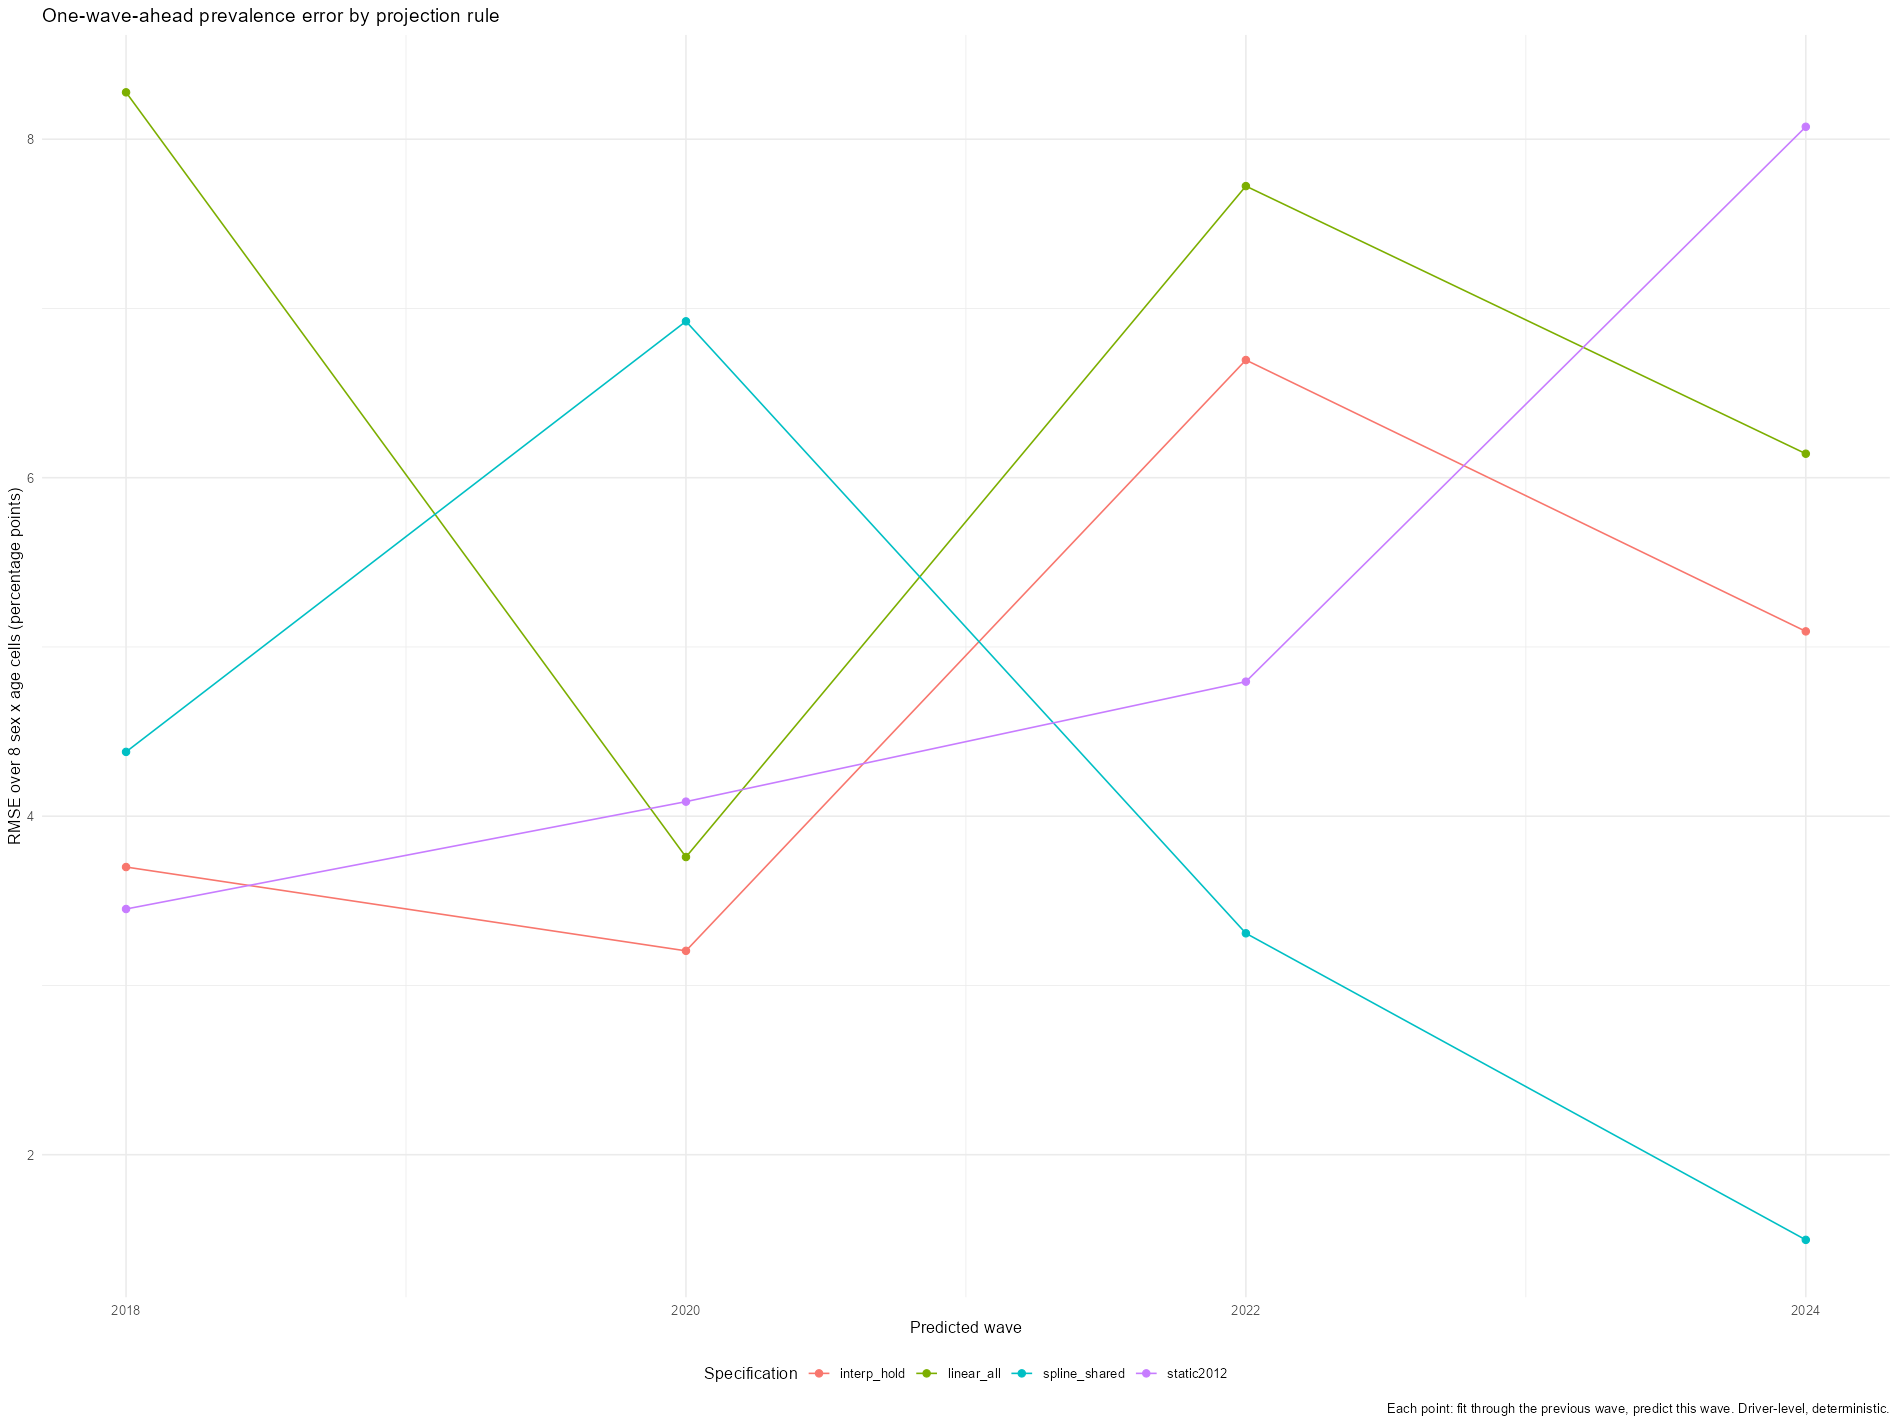

In [16]:
#| label: ms-rolling-origin
.t0 <- Sys.time()
ms_rolling_grid <- base::expand.grid(cutoff = ms_cfg$cutoffs, spec = ms_cfg$specs,
  drop_2020 = base::c(FALSE, TRUE), stringsAsFactors = FALSE)
ms_rolling_grid <- ms_rolling_grid[!ms_rolling_grid$drop_2020 | ms_rolling_grid$cutoff >= 2020L, ]
ms_rolling <- dplyr::bind_rows(base::lapply(base::seq_len(base::nrow(ms_rolling_grid)), function(i) {
  g <- ms_rolling_grid[i, ]
  model <- ms_fit(g$cutoff, g$spec, g$drop_2020)
  eval_years <- ms_wave_years[ms_wave_years > g$cutoff & ms_wave_years <= g$cutoff + 4L]
  d <- ms_drivers(model, eval_years)
  obs <- ms_targets[ms_targets$year %in% eval_years, ]
  k <- base::match(base::paste(obs$year, obs$sex, obs$age_group, sep = ":"), d$key)
  base::stopifnot(!base::anyNA(k))
  base::data.frame(cutoff = g$cutoff, spec = g$spec, drop_2020 = g$drop_2020, year = obs$year,
    horizon_waves = (obs$year - g$cutoff) %/% 2L, sex = obs$sex, age_group = obs$age_group,
    current_observed = obs$current_mean, current_predicted = d$p_current[k], current_se = obs$current_se,
    gpd_observed = obs$gpd_mean, gpd_predicted = d$mu_current[k], gpd_se = obs$gpd_se)
}))
ms_rolling$current_error <- ms_rolling$current_predicted - ms_rolling$current_observed
ms_rolling$gpd_error <- ms_rolling$gpd_predicted - ms_rolling$gpd_observed
ms_rolling$current_in_interval <- base::ifelse(ms_rolling$year == 2020L, NA,
  base::abs(ms_rolling$current_error) <= stats::qnorm(0.975) * ms_rolling$current_se)
base::stopifnot(base::nrow(ms_rolling) == 8L * (3L * 2L + 1L) * 4L + 8L * (2L + 1L) * 4L)
ms_rolling_metrics <- ms_rolling |>
  dplyr::group_by(spec, drop_2020, horizon_waves) |>
  dplyr::summarise(cutoffs = dplyr::n_distinct(cutoff), cells = dplyr::n(),
    current_bias = base::mean(current_error), current_rmse = base::sqrt(base::mean(current_error^2)),
    current_working_coverage = base::mean(current_in_interval, na.rm = TRUE),
    gpd_bias = base::mean(gpd_error), gpd_rmse = base::sqrt(base::mean(gpd_error^2)), .groups = "drop") |>
  dplyr::arrange(drop_2020, horizon_waves, current_rmse)
ms_rolling_by_cutoff <- ms_rolling |>
  dplyr::filter(!drop_2020, horizon_waves == 1L) |>
  dplyr::group_by(spec, cutoff, target_year = year) |>
  dplyr::summarise(current_rmse_pp = 100 * base::sqrt(base::mean(current_error^2)),
    current_bias_pp = 100 * base::mean(current_error),
    gpd_rmse = base::sqrt(base::mean(gpd_error^2)), .groups = "drop")
ms_rolling_wide <- ms_rolling_by_cutoff |>
  dplyr::select(spec, target_year, current_rmse_pp) |>
  tidyr::pivot_wider(names_from = target_year, values_from = current_rmse_pp, names_prefix = "predict_")
ms_table(ms_rolling_metrics, "Rolling-origin summary across cutoffs; proportions for prevalence, g/day for intensity")
ms_table(ms_rolling_wide, "One-wave-ahead prevalence RMSE in percentage points by cutoff (all waves retained)")
ms_fig_rolling <- ggplot2::ggplot(ms_rolling_by_cutoff, ggplot2::aes(target_year, current_rmse_pp, colour = spec)) +
  ggplot2::geom_line() + ggplot2::geom_point(size = 2) +
  ggplot2::scale_x_continuous(breaks = base::unique(ms_rolling_by_cutoff$target_year)) +
  ggplot2::labs(title = "One-wave-ahead prevalence error by projection rule", x = "Predicted wave",
    y = "RMSE over 8 sex x age cells (percentage points)", colour = "Specification",
    caption = "Each point: fit through the previous wave, predict this wave. Driver-level, deterministic.") +
  ggplot2::theme_minimal(base_size = 11) + ggplot2::theme(legend.position = "bottom")
base::print(ms_fig_rolling)
base::message(base::sprintf("ms-rolling-origin elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


Section 9 does not identify a clearly superior forecasting rule. Instead, it shows that persistence is difficult to beat and that the post-2020 decline in prevalence was largely unpredictable from the historical survey margins available before 2020. That finding is more important than the small differences in average RMSE among specifications.

## 10. Microsimulation confirmation at the 2020 cutoff and the 2020 sensitivity

The baseline reported held-out 2022/2024 prevalence RMSE of 10.26 points for `linear_all` and 6.34 for `static2012`. Here every specification is run through the full engine from the 2020 cutoff with the five seeds, so that (a) the rolling-origin driver numbers are confirmed by the engine, (b) the baseline numbers are reproduced under new seeds, and (c) HED—only observable through the engine—is included. The driver-identity check compares the five-seed mean cell prevalence with the driver value.

The 2020 sensitivity then repeats the cutoff-2020 and cutoff-2022 evaluations with the 2020 wave removed from all consumption fits. If the ranking of rules is unchanged, the conclusion does not hinge on 2020; if it changes, the wave's comparability (Section 6) becomes a first-order question.


In [17]:
#| label: ms-holdout-2020-by-spec
.t0 <- Sys.time()
ms_holdout_runs <- base::lapply(ms_cfg$specs, function(spec) base::lapply(ms_cfg$seeds, function(seed)
  ms_simulate(ms_train_models[[spec]], 2012:2024, ms_cfg$n_sim, seed, ms_cfg$rho)))
base::names(ms_holdout_runs) <- ms_cfg$specs
ms_holdout_summary <- dplyr::bind_rows(base::lapply(ms_cfg$specs, function(spec)
  dplyr::bind_rows(base::lapply(ms_holdout_runs[[spec]], `[[`, "summary")) |> dplyr::mutate(spec = spec)))
ms_holdout_cells <- ms_holdout_summary |>
  dplyr::group_by(spec, year, sex, age_group) |>
  dplyr::summarise(current_mc_sd = stats::sd(current_mean), gpd_mc_sd = stats::sd(gpd_mean),
    hed_mc_sd = stats::sd(hed_mean), current_mean = base::mean(current_mean),
    gpd_mean = base::mean(gpd_mean), hed_mean = base::mean(hed_mean), n_pooled = base::sum(n), .groups = "drop") |>
  dplyr::inner_join(ms_targets, by = base::c("year", "sex", "age_group"), suffix = base::c("_simulated", "_observed"))
base::stopifnot(base::nrow(ms_holdout_cells) == 56L * base::length(ms_cfg$specs))
# Driver identity: pooled-seed cell prevalence must match the driver value within binomial Monte Carlo noise.
# Cells differ in size (60-65 is six ages), so the tolerance is a z-score, not a fixed gap.
ms_driver_identity <- dplyr::bind_rows(base::lapply(ms_cfg$specs, function(spec) {
  d <- ms_drivers(ms_train_models[[spec]], 2012:2024)
  s <- ms_holdout_cells[ms_holdout_cells$spec == spec, ]
  k <- base::match(base::paste(s$year, s$sex, s$age_group, sep = ":"), d$key)
  gap <- s$current_mean_simulated - d$p_current[k]
  z <- gap / base::sqrt(d$p_current[k] * (1 - d$p_current[k]) / s$n_pooled)
  base::data.frame(spec = spec, cells = base::length(gap), max_abs_gap_current = base::max(base::abs(gap)),
    mean_abs_gap_current = base::mean(base::abs(gap)), max_abs_z = base::max(base::abs(z)),
    mean_squared_z = base::mean(z^2), max_abs_gap_gpd = base::max(base::abs(s$gpd_mean_simulated - d$mu_current[k])))
}))
ms_table(ms_driver_identity, "Driver identity check: engine margins reproduce driver curves (binomial z over pooled seeds)")
base::stopifnot(base::all(ms_driver_identity$max_abs_z < 5), base::all(ms_driver_identity$mean_squared_z < 2))
ms_holdout_long <- dplyr::bind_rows(base::lapply(base::c("current", "gpd", "hed"), function(m)
  base::data.frame(spec = ms_holdout_cells$spec, year = ms_holdout_cells$year, sex = ms_holdout_cells$sex,
    age_group = ms_holdout_cells$age_group, metric = m,
    observed = ms_holdout_cells[[base::paste0(m, "_mean_observed")]],
    simulated = ms_holdout_cells[[base::paste0(m, "_mean_simulated")]],
    se = ms_holdout_cells[[base::paste0(m, "_se")]], mc_sd = ms_holdout_cells[[base::paste0(m, "_mc_sd")]]))) |>
  dplyr::mutate(error = simulated - observed,
    period = base::ifelse(year <= ms_cfg$train_end, "Training 2012-2020", "Post-cutoff 2022/2024"),
    in_working_interval = base::ifelse(year == 2020L, NA, base::abs(error) <= stats::qnorm(0.975) * se))
ms_holdout_metrics <- ms_holdout_long |>
  dplyr::group_by(spec, period, metric) |>
  dplyr::summarise(cells = dplyr::n(), bias = base::mean(error), rmse = base::sqrt(base::mean(error^2)),
    working_interval_coverage = base::mean(in_working_interval, na.rm = TRUE),
    mean_monte_carlo_sd = base::mean(mc_sd), .groups = "drop") |>
  dplyr::arrange(period, metric, rmse)
ms_table(ms_holdout_metrics[ms_holdout_metrics$period == "Post-cutoff 2022/2024", ],
  "Engine-based 2022/2024 comparison by specification, fitted through 2020, five seeds")
ms_table(ms_holdout_metrics[ms_holdout_metrics$period == "Training 2012-2020", ],
  "Training-period fit by specification (in-sample for all but static2012)")
# 2020 sensitivity: same rolling-origin evaluation with the 2020 wave dropped from consumption fits.
ms_sens_2020 <- ms_rolling |>
  dplyr::filter(cutoff >= 2020L, horizon_waves == 1L) |>
  dplyr::group_by(spec, cutoff, target_year = year, drop_2020) |>
  dplyr::summarise(current_rmse_pp = 100 * base::sqrt(base::mean(current_error^2)),
    current_bias_pp = 100 * base::mean(current_error), .groups = "drop") |>
  dplyr::mutate(wave2020 = base::ifelse(drop_2020, "without2020", "with2020"), drop_2020 = NULL) |>
  tidyr::pivot_wider(names_from = wave2020, values_from = c(current_rmse_pp, current_bias_pp),  # tidyselect helper, not base::c
    names_glue = "{.value}_{wave2020}") |>
  dplyr::arrange(target_year, current_rmse_pp_with2020)
ms_table(ms_sens_2020, "2020 sensitivity: one-wave-ahead prevalence error with and without the 2020 wave")
base::message(base::sprintf("ms-holdout-2020-by-spec elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




Table: Driver identity check: engine margins reproduce driver curves (binomial z over pooled seeds)

|spec          | cells| max_abs_gap_current| mean_abs_gap_current| max_abs_z| mean_squared_z| max_abs_gap_gpd|
|:-------------|-----:|-------------------:|--------------------:|---------:|--------------:|---------------:|
|static2012    |    56|              0.0148|               0.0038|    2.4040|         1.0946|          0.2596|
|interp_hold   |    56|              0.0180|               0.0041|    2.6176|         1.2175|          0.2397|
|linear_all    |    56|              0.0135|               0.0039|    2.4539|         1.1042|          0.2211|
|spline_shared |    56|              0.0160|               0.0042|    2.4718|         1.2602|          0.2166|


Table: Engine-based 2022/2024 comparison by specification, fitted through 2020, five seeds

|spec          |period                |metric  | cells|    bias|   rmse| working_interval_coverage| mean_monte_carlo_sd|
|:-------------|

## 11. Seven-wave reconstruction 2012–2024

`interp_hold` fitted to all seven waves gives driver curves that pass through every survey estimate; odd years are interpolated on the logit/log scale, so prevalence is (0,1) gr. per day are not negative (log), linked by straight lines. Five engine runs report how closely the simulated population reproduces those targets and how large Monte Carlo variation is (5x25,000 = 125,000). Because the targets are the calibration inputs, agreement here is expected by construction; it measures engine noise and the effect of within-cell age composition, not predictive validity (simulation should reproduce these curves, so it should be consistent, the deviation should be due to Monte Carlo noise). The value of this run is that it is a complete, documented 2012–2024 synthetic population with explicit transition assumptions, which is what the ACC commitment requires.



Table: Reconstruction fit 2012-2024: proportions for prevalence/HED, g/day for intensity

|metric  | cells|    bias|   rmse|    mae| working_interval_coverage| mean_monte_carlo_sd|interpretation                                                           |
|:-------|-----:|-------:|------:|------:|-------------------------:|-------------------:|:------------------------------------------------------------------------|
|current |    56| -0.0003| 0.0051| 0.0039|                     1.000|              0.0093|Seven-wave calibration reproduced by the engine; not held-out validation |
|gpd     |    56| -0.0222| 0.1060| 0.0840|                     1.000|              0.1763|Seven-wave calibration reproduced by the engine; not held-out validation |
|hed     |    56| -0.0450| 0.0639| 0.0506|                     0.625|              0.0132|Seven-wave calibration reproduced by the engine; not held-out validation |


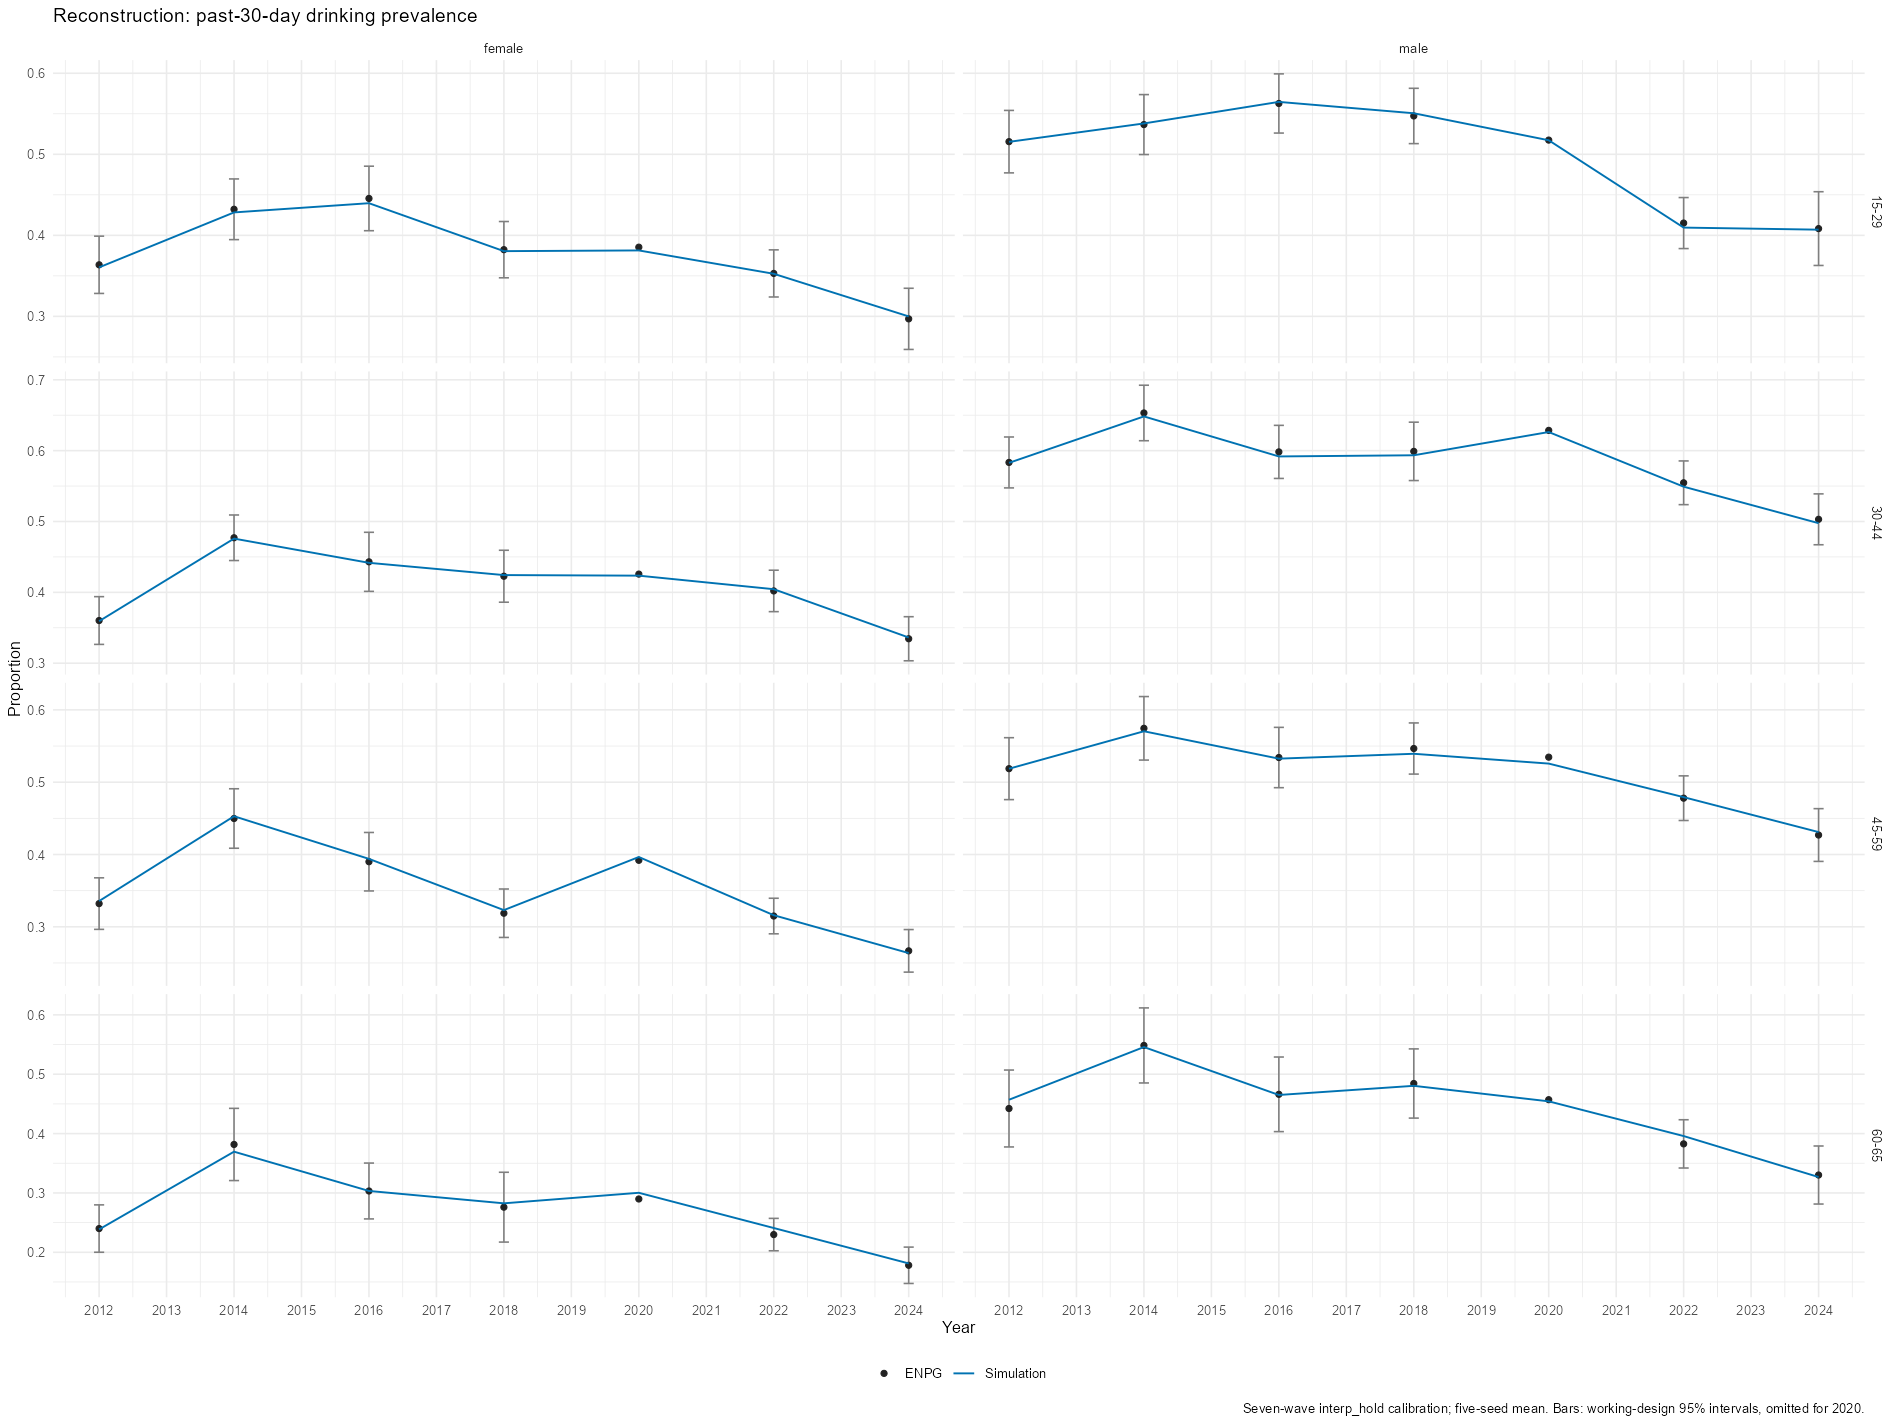

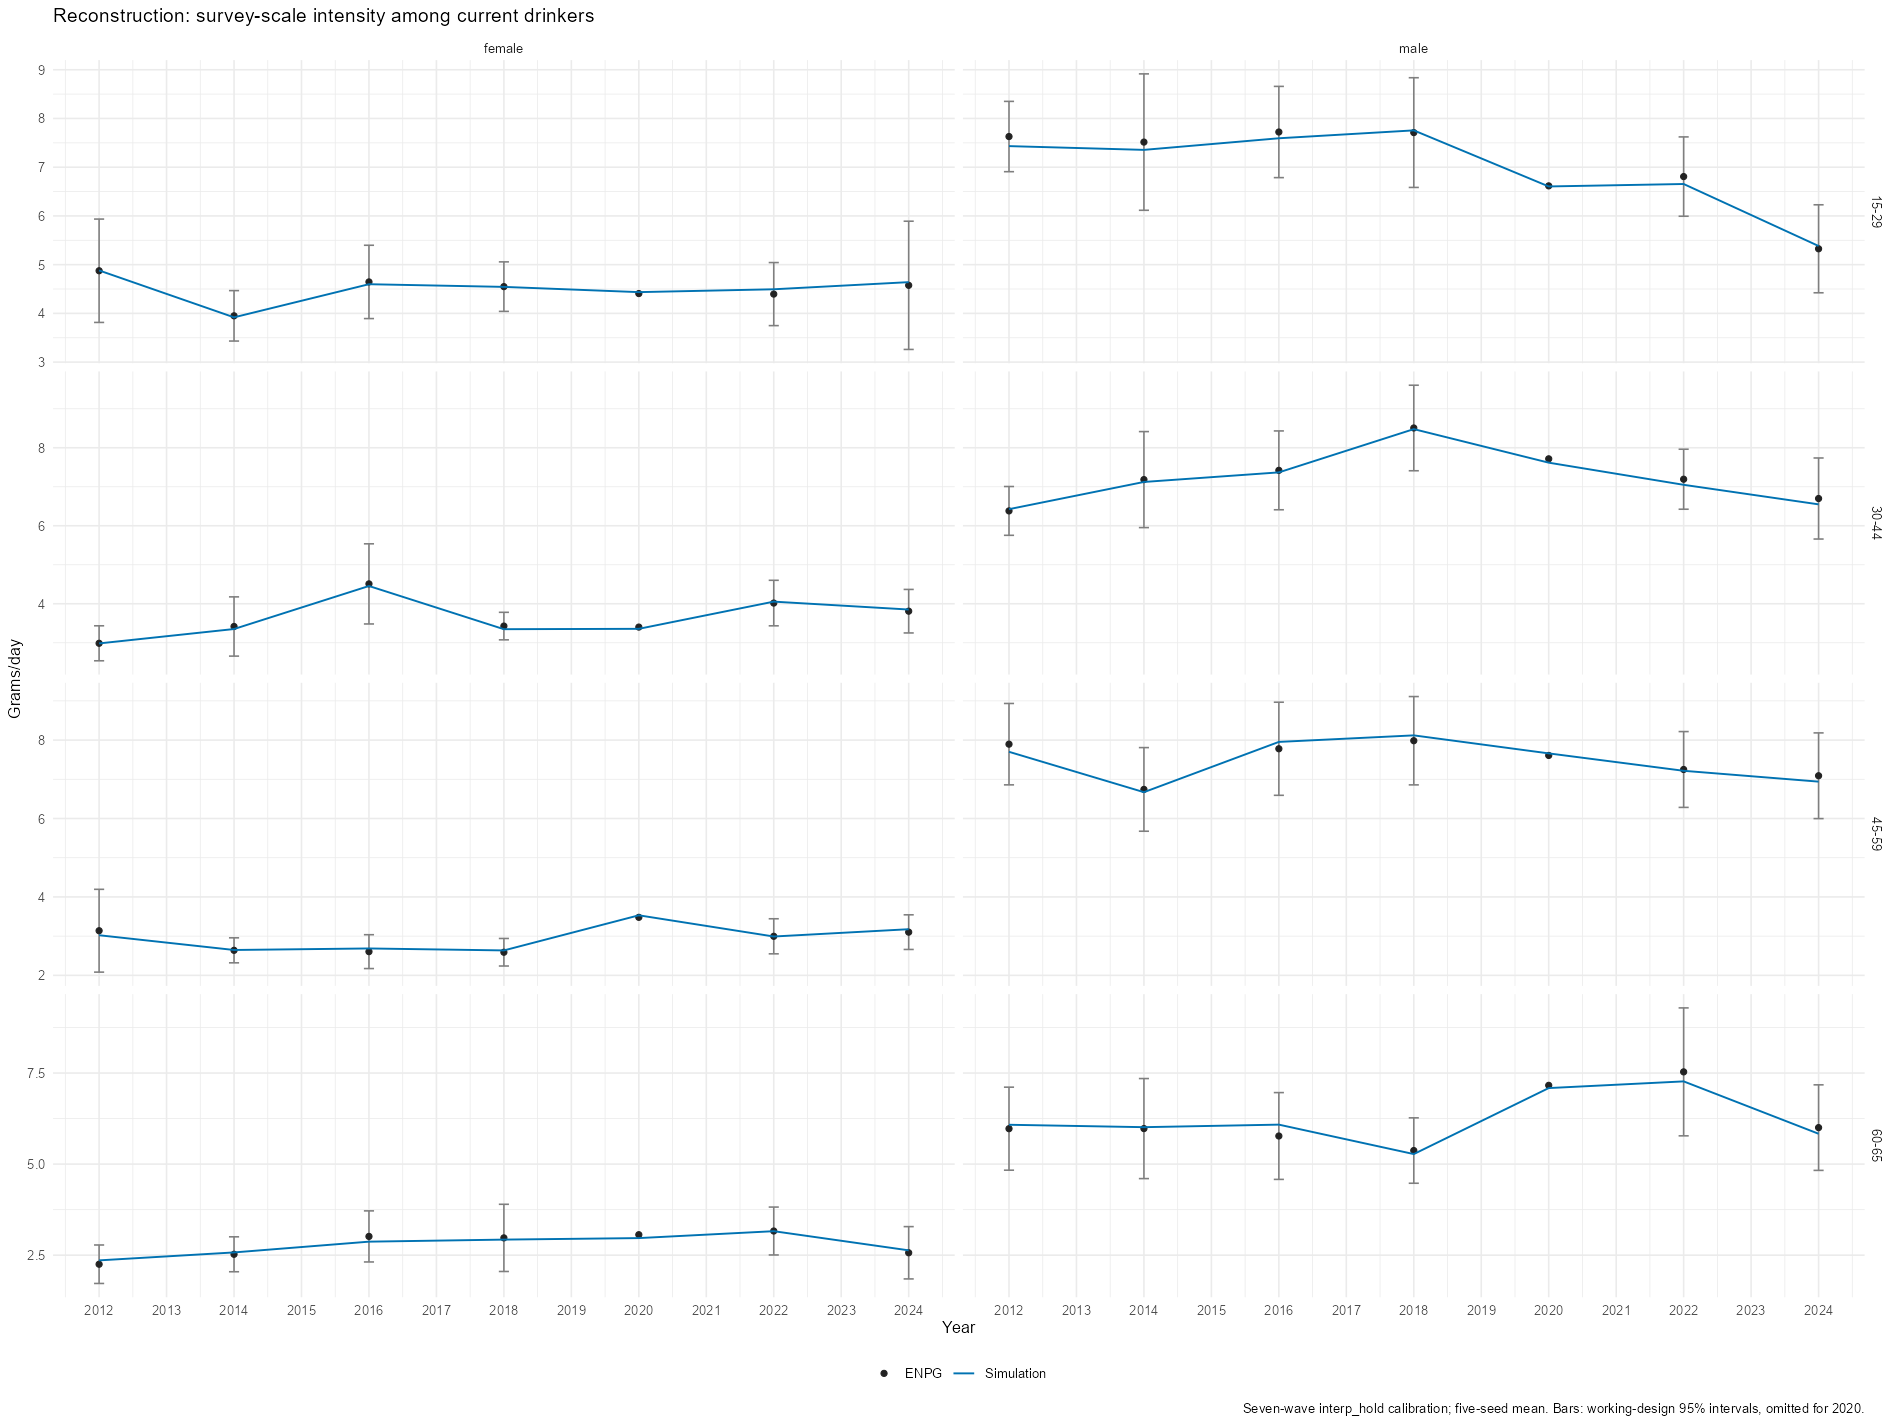

ms-reconstruction elapsed minutes: 0.13


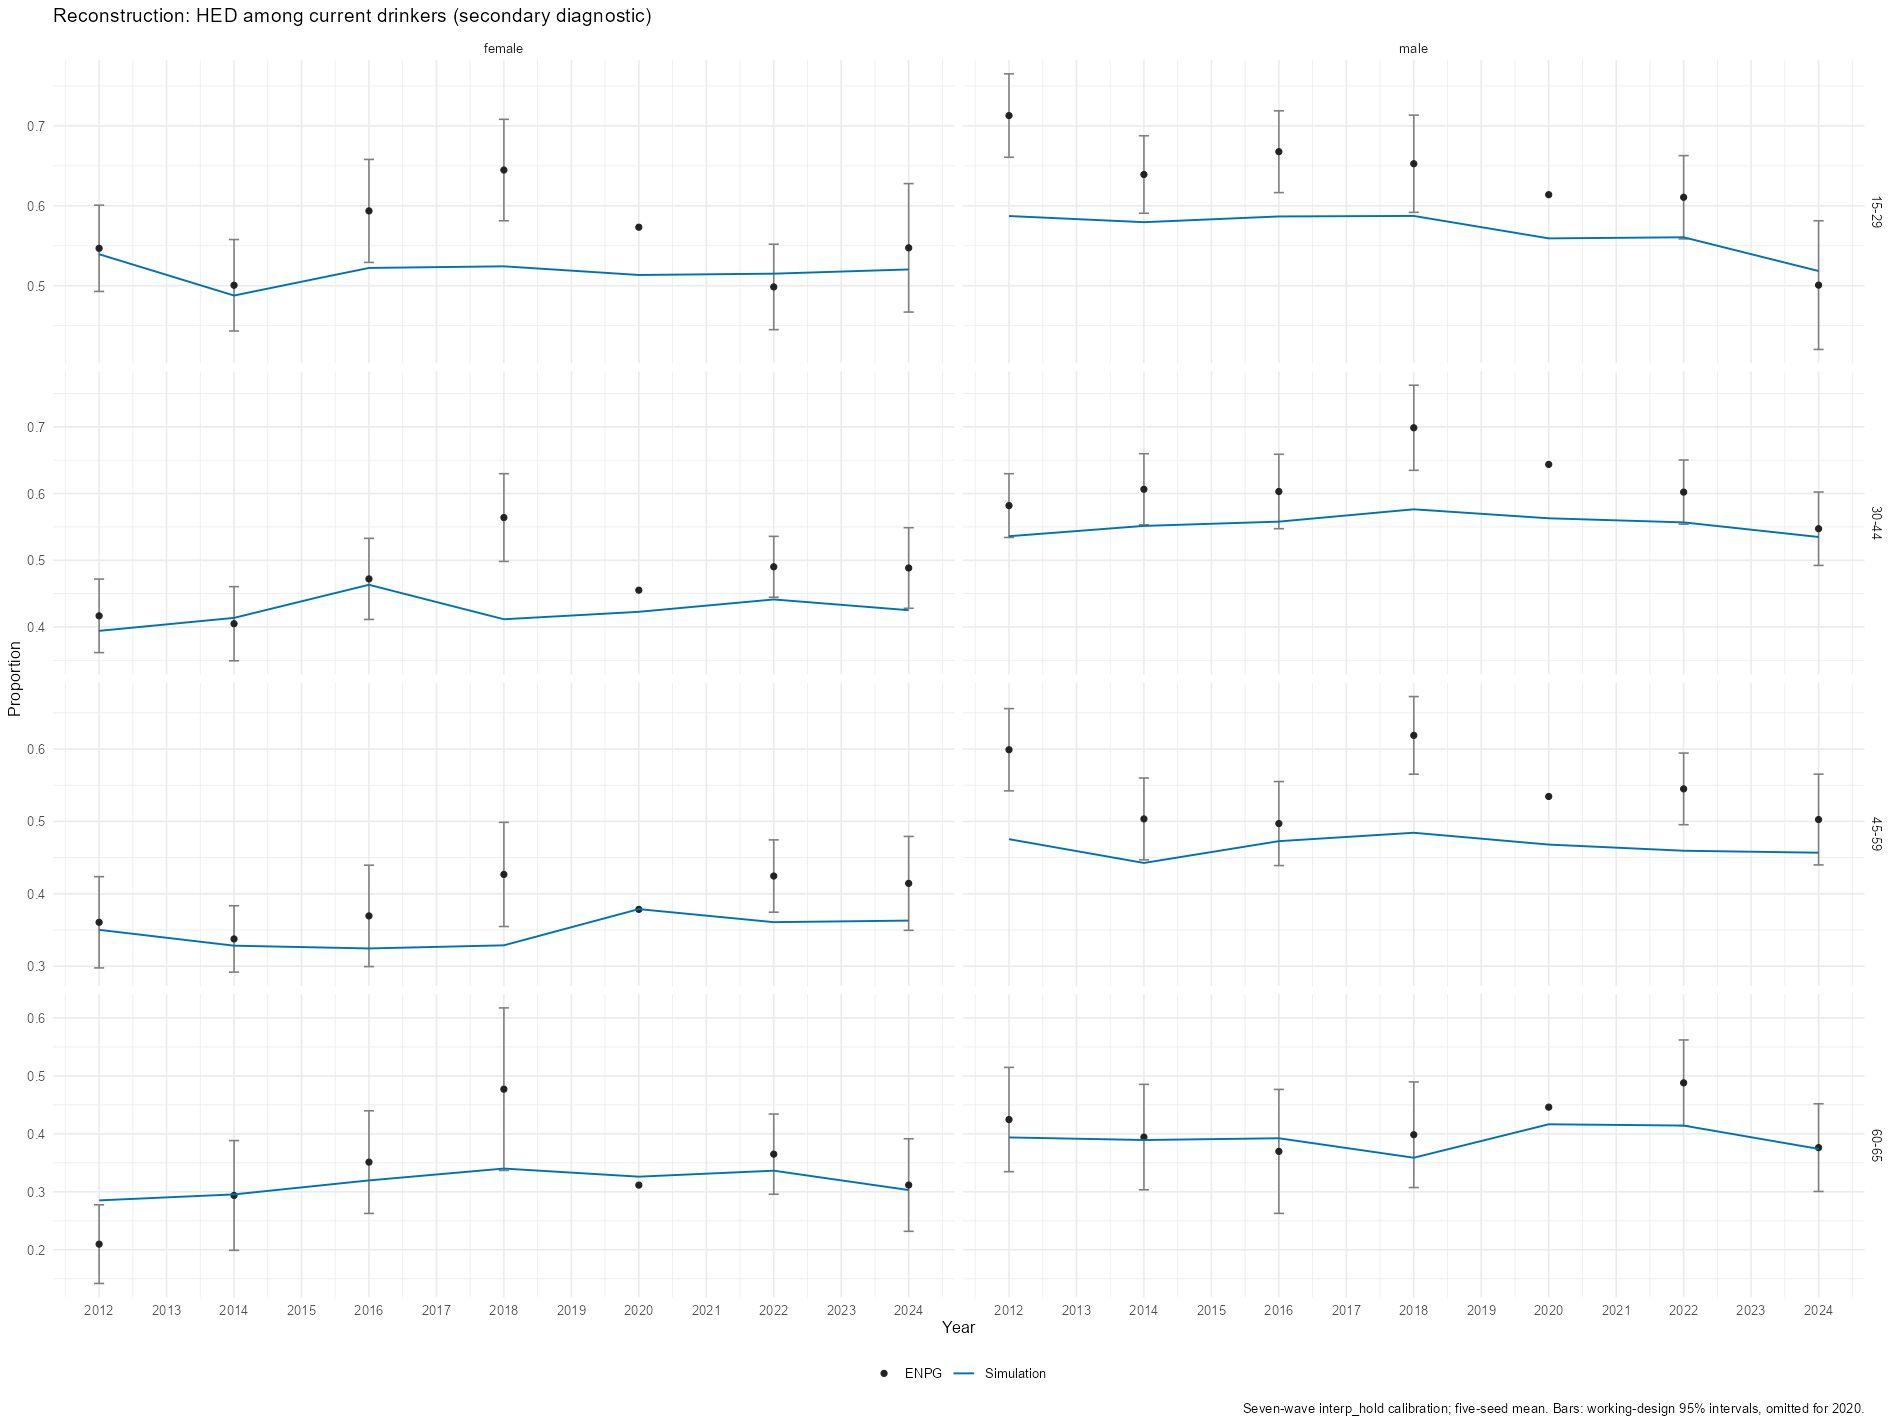

In [19]:
#| label: ms-reconstruction
.t0 <- Sys.time()
ms_reconstruction_model <- ms_fit(ms_cfg$observed_end, "interp_hold")
base::stopifnot(base::setequal(ms_reconstruction_model$training_years, ms_wave_years))
ms_reconstruction_runs <- base::lapply(ms_cfg$seeds, function(seed)
  ms_simulate(ms_reconstruction_model, 2012:2024, ms_cfg$n_sim, seed, ms_cfg$rho))
ms_reconstruction_summary <- dplyr::bind_rows(base::lapply(ms_reconstruction_runs, `[[`, "summary"))
ms_reconstruction_deaths <- dplyr::bind_rows(base::lapply(ms_reconstruction_runs, `[[`, "deaths"))
ms_reconstruction_cells <- ms_reconstruction_summary |>
  dplyr::group_by(year, sex, age_group) |>
  dplyr::summarise(current_mc_sd = stats::sd(current_mean), gpd_mc_sd = stats::sd(gpd_mean),
    hed_mc_sd = stats::sd(hed_mean), current_mean = base::mean(current_mean),
    gpd_mean = base::mean(gpd_mean), hed_mean = base::mean(hed_mean), .groups = "drop") |>
  dplyr::inner_join(ms_targets, by = base::c("year", "sex", "age_group"), suffix = base::c("_simulated", "_observed"))
base::stopifnot(base::nrow(ms_reconstruction_cells) == 56L)
ms_reconstruction_long <- dplyr::bind_rows(base::lapply(base::c("current", "gpd", "hed"), function(m)
  base::data.frame(year = ms_reconstruction_cells$year, sex = ms_reconstruction_cells$sex,
    age_group = ms_reconstruction_cells$age_group, metric = m,
    observed = ms_reconstruction_cells[[base::paste0(m, "_mean_observed")]],
    simulated = ms_reconstruction_cells[[base::paste0(m, "_mean_simulated")]],
    se = ms_reconstruction_cells[[base::paste0(m, "_se")]],
    mc_sd = ms_reconstruction_cells[[base::paste0(m, "_mc_sd")]],
    design_status = ms_reconstruction_cells$design_status))) |>
  dplyr::mutate(error = simulated - observed, standardized_error = error / se,
    in_working_interval = base::ifelse(year == 2020L, NA, base::abs(error) <= stats::qnorm(0.975) * se))
ms_reconstruction_metrics <- ms_reconstruction_long |>
  dplyr::group_by(metric) |>
  dplyr::summarise(cells = dplyr::n(), bias = base::mean(error), rmse = base::sqrt(base::mean(error^2)),
    mae = base::mean(base::abs(error)), working_interval_coverage = base::mean(in_working_interval, na.rm = TRUE),
    mean_monte_carlo_sd = base::mean(mc_sd), .groups = "drop") |>
  dplyr::mutate(interpretation = "Seven-wave calibration reproduced by the engine; not held-out validation")
ms_table(ms_reconstruction_metrics, "Reconstruction fit 2012-2024: proportions for prevalence/HED, g/day for intensity")
ms_plot <- function(d, title, y_label, caption) {
  d$age_band <- base::factor(d$age_group, levels = 1:4, labels = base::c("15-29", "30-44", "45-59", "60-65"))
  ggplot2::ggplot(d, ggplot2::aes(year)) +
    ggplot2::geom_errorbar(ggplot2::aes(ymin = observed - 1.96 * se, ymax = observed + 1.96 * se),
      data = d[d$year != 2020L, ], width = 0.15, colour = "grey50") +
    ggplot2::geom_point(ggplot2::aes(y = observed, colour = "ENPG"), size = 1.6) +
    ggplot2::geom_line(ggplot2::aes(y = simulated, colour = "Simulation"), linewidth = 0.6) +
    ggplot2::facet_grid(age_band ~ sex, scales = "free_y") +
    ggplot2::scale_colour_manual(values = base::c(ENPG = "#222222", Simulation = "#0072B2")) +
    ggplot2::labs(title = title, x = "Year", y = y_label, colour = NULL, caption = caption) +
    ggplot2::scale_x_continuous(
      breaks = 2012:2024,
      labels = 2012:2024
    ) +
    ggplot2::theme_minimal(base_size = 11) + ggplot2::theme(legend.position = "bottom")
}
ms_caption_recon <- "Seven-wave interp_hold calibration; five-seed mean. Bars: working-design 95% intervals, omitted for 2020."
ms_fig_recon_prevalence <- ms_plot(ms_reconstruction_long[ms_reconstruction_long$metric == "current", ],
  "Reconstruction: past-30-day drinking prevalence", "Proportion", ms_caption_recon)
ms_fig_recon_intensity <- ms_plot(ms_reconstruction_long[ms_reconstruction_long$metric == "gpd", ],
  "Reconstruction: survey-scale intensity among current drinkers", "Grams/day", ms_caption_recon)
ms_fig_recon_hed <- ms_plot(ms_reconstruction_long[ms_reconstruction_long$metric == "hed", ],
  "Reconstruction: HED among current drinkers (secondary diagnostic)", "Proportion", ms_caption_recon)
base::print(ms_fig_recon_prevalence)
base::print(ms_fig_recon_intensity)
base::print(ms_fig_recon_hed)
base::message(base::sprintf("ms-reconstruction elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


## 12. Mortality concordance for the reconstruction run

Unchanged logic from the baseline: expected and realized simulated deaths against DEIS, with the HMD mx × June-population benchmark. The multiplier is now calibrated on DEIS 2012–2024, so all years are in-sample for the aggregate level; age/year-specific discrepancies remain visible. These are all-cause deaths independent of alcohol exposure.


In [20]:
#| label: ms-mortality-concordance
.t0 <- Sys.time()
ms_mortality_comparison <- ms_reconstruction_deaths |>
  dplyr::group_by(year, sex, seed) |>
  dplyr::summarise(simulated_deaths = base::sum(deaths), expected_deaths = base::sum(expected_deaths),
    .groups = "drop") |>
  dplyr::group_by(year, sex) |>
  dplyr::summarise(mc_sd = stats::sd(simulated_deaths),
    simulated_deaths = base::mean(simulated_deaths),
    expected_deaths = base::mean(expected_deaths), .groups = "drop") |>
  dplyr::left_join(ms_mortality |>
    dplyr::group_by(year, sex) |>
    dplyr::summarise(observed_deaths = base::sum(deaths),
      hmd_mx_expected = base::sum(mx * pop_mid), .groups = "drop"), by = base::c("year", "sex")) |>
  dplyr::mutate(expected_relative_error = expected_deaths / observed_deaths - 1)
ms_table(ms_mortality_comparison, "DEIS concordance for the seven-wave reconstruction; multiplier calibrated on 2012-2024")
base::stopifnot(base::all(base::is.finite(ms_mortality_comparison$mc_sd)))
ms_mortality_mc <- ms_reconstruction_deaths |>
  dplyr::group_by(seed) |>
  dplyr::summarise(realized = base::sum(deaths), expected = base::sum(expected_deaths),
    conditional_sd = base::sqrt(base::sum(mc_variance)), .groups = "drop") |>
  dplyr::mutate(z_mc = (realized - expected) / conditional_sd)
ms_table(ms_mortality_mc, "Monte Carlo death diagnostic; not a test of epidemiological validity")
ms_table(base::data.frame(sex = base::names(ms_reconstruction_model$mortality_scale),
  hazard_multiplier = base::unname(ms_reconstruction_model$mortality_scale)), "Mortality multipliers, DEIS 2012-2024")
base::message(base::sprintf("ms-mortality-concordance elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




Table: DEIS concordance for the seven-wave reconstruction; multiplier calibrated on 2012-2024

| year|sex    |     mc_sd| simulated_deaths| expected_deaths| observed_deaths| hmd_mx_expected| expected_relative_error|
|----:|:------|---------:|----------------:|---------------:|---------------:|---------------:|-----------------------:|
| 2012|female | 1198.3014|         8566.240|        9761.005|            9916|        10285.63|                 -0.0156|
| 2012|male   | 2444.4440|        20019.977|       17375.954|           17908|        18772.71|                 -0.0297|
| 2013|female | 2463.3203|         9239.989|        9935.450|           10065|        10465.85|                 -0.0129|
| 2013|male   | 2391.7661|        17709.979|       18185.431|           18663|        19635.92|                 -0.0256|
| 2014|female | 2372.3206|         9336.239|        9890.250|            9986|        10405.38|                 -0.0096|
| 2014|male   | 3918.5645|        19442.477|       18266

After calibration of sex-specific hazard multipliers (women 0.9645, men 0.9413), the engine's expected annual deaths matched DEIS counts closely over 2012–2024: relative errors ranged from −3.0% to +3.4% across the 26 sex-year strata, drifting from negative in the early years to positive in the latest (men: −3.0% in 2012, +3.4% in 2024), so a single multiplier averages a slow HMD–DEIS divergence. Simulated annual counts are noisier: with 25,000 simulated people per run, the Monte Carlo SD of a stratum-year count has a median of 14% of the observed deaths, and the five-seed mean differs from DEIS by more than 10% in 38% of strata. Realized totals were nonetheless consistent with their conditional expectations (standardized deviations between −1.1 and +0.5 across five seeds). Because the multipliers were estimated on the same 2012–2024 period and the hazards come from HMD life tables that already include the 2020–2021 excess, these results are an internal calibration diagnostic, not an external validation.

## 13. Persistence sensitivity with the reconstruction model

Same seed and demographic process for rho = 0, 0.8 and 0.95. The time curve now reproduces the observed margins, so this table isolates what the margins cannot identify: annual status changes and synthetic never/former histories. Rho is not adjusted to improve any fit.


In [21]:
#| label: ms-persistence-sensitivity
.t0 <- Sys.time()
ms_sensitivity <- dplyr::bind_rows(base::lapply(base::c(0, ms_cfg$rho, 0.95), function(rho) {
  run <- ms_simulate(ms_reconstruction_model, 2012:2024, ms_cfg$n_sim, ms_cfg$seeds[1], rho)
  last <- run$summary[run$summary$year == 2024L, ]
  base::data.frame(rho = rho,
    annual_current_status_change = base::sum(run$flows$status_changes) / base::sum(run$flows$transition_n),
    current_2024 = stats::weighted.mean(last$current_mean, last$n),
    never_2024 = stats::weighted.mean(last$never, last$n),
    former_2024 = stats::weighted.mean(last$former, last$n),
    deaths_total = base::sum(run$deaths$deaths))
}))
base::stopifnot(base::length(base::unique(ms_sensitivity$deaths_total)) == 1L)
ms_table(ms_sensitivity, "Persistence changes synthetic histories; the 2024 margin is fixed by calibration")
base::message(base::sprintf("ms-persistence-sensitivity elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




Table: Persistence changes synthetic histories; the 2024 margin is fixed by calibration

|  rho| annual_current_status_change| current_2024| never_2024| former_2024| deaths_total|
|----:|----------------------------:|------------:|----------:|-----------:|------------:|
| 0.00|                       0.4802|       0.3671|     0.0181|      0.6148|     395105.8|
| 0.80|                       0.1988|       0.3627|     0.0627|      0.5746|     395105.8|
| 0.95|                       0.1004|       0.3589|     0.1275|      0.5136|     395105.8|
ms-persistence-sensitivity elapsed minutes: 0.06


In the current model, ρ affects individual drinking trajectories and population groups defined by drinking history, including the proportions of never drinkers and former drinkers, as well as the annual rate of status change. For example, when ρ increases from 0 to 0.95, the annual rate of current-drinking status change decreases from approximately 48% to 10%, while the proportion of never drinkers in 2024 increases from approximately 2% to 13%. However, it does not materially affect the calibrated annual margins or total deaths. Annual prevalence and consumption intensity are determined by the calibrated curves, while mortality is currently independent of alcohol exposure. Therefore, the identical death totals should not be interpreted as evidence that persistence is unimportant for future population outcomes. Once exposure histories are linked to mortality, former-drinker relative risks, lagged effects, repeated interventions, PIF, and YPLL, ρ may affect these outcomes. At present, ρ is not identified by the marginal data and should not be used to improve marginal fit. The small difference in 2024 prevalence across ρ values is within Monte Carlo variability and should not be interpreted as a real effect.

## 14. Projection 2025–2034 under three explicit rules

Each rule is fitted to all seven waves and run through 2034 with seed 2125; INE stocks evolve, HMD qx and the mortality multiplier stay at 2024. `interp_hold` keeps 2024 prevalence and intensity fixed; `linear_all` extrapolates each cell's 2012–2024 trend; `spline_shared` extrapolates the shared curve linearly beyond 2024. The rolling-origin table is the evidence for preferring one rule; the spread between rules is a minimal, structural projection range—not a confidence interval and not an official forecast.




Table: National 15-65 prevalence, intensity and expected all-cause deaths by projection rule

|spec          | year| current_prevalence| gpd_current| gpd_population| expected_deaths|
|:-------------|----:|------------------:|-----------:|--------------:|---------------:|
|interp_hold   | 2024|             0.3627|      5.3019|         1.9230|        32724.64|
|interp_hold   | 2029|             0.3585|      5.2308|         1.8754|        34430.99|
|interp_hold   | 2034|             0.3621|      5.4095|         1.9590|        35531.54|
|linear_all    | 2024|             0.3980|      5.6642|         2.2544|        32724.64|
|linear_all    | 2029|             0.3540|      5.6807|         2.0110|        34430.99|
|linear_all    | 2034|             0.3210|      5.9308|         1.9037|        35531.54|
|spline_shared | 2024|             0.3598|      5.6093|         2.0183|        32724.64|
|spline_shared | 2029|             0.2378|      5.3170|         1.2646|        34430.99|
|spline_shared

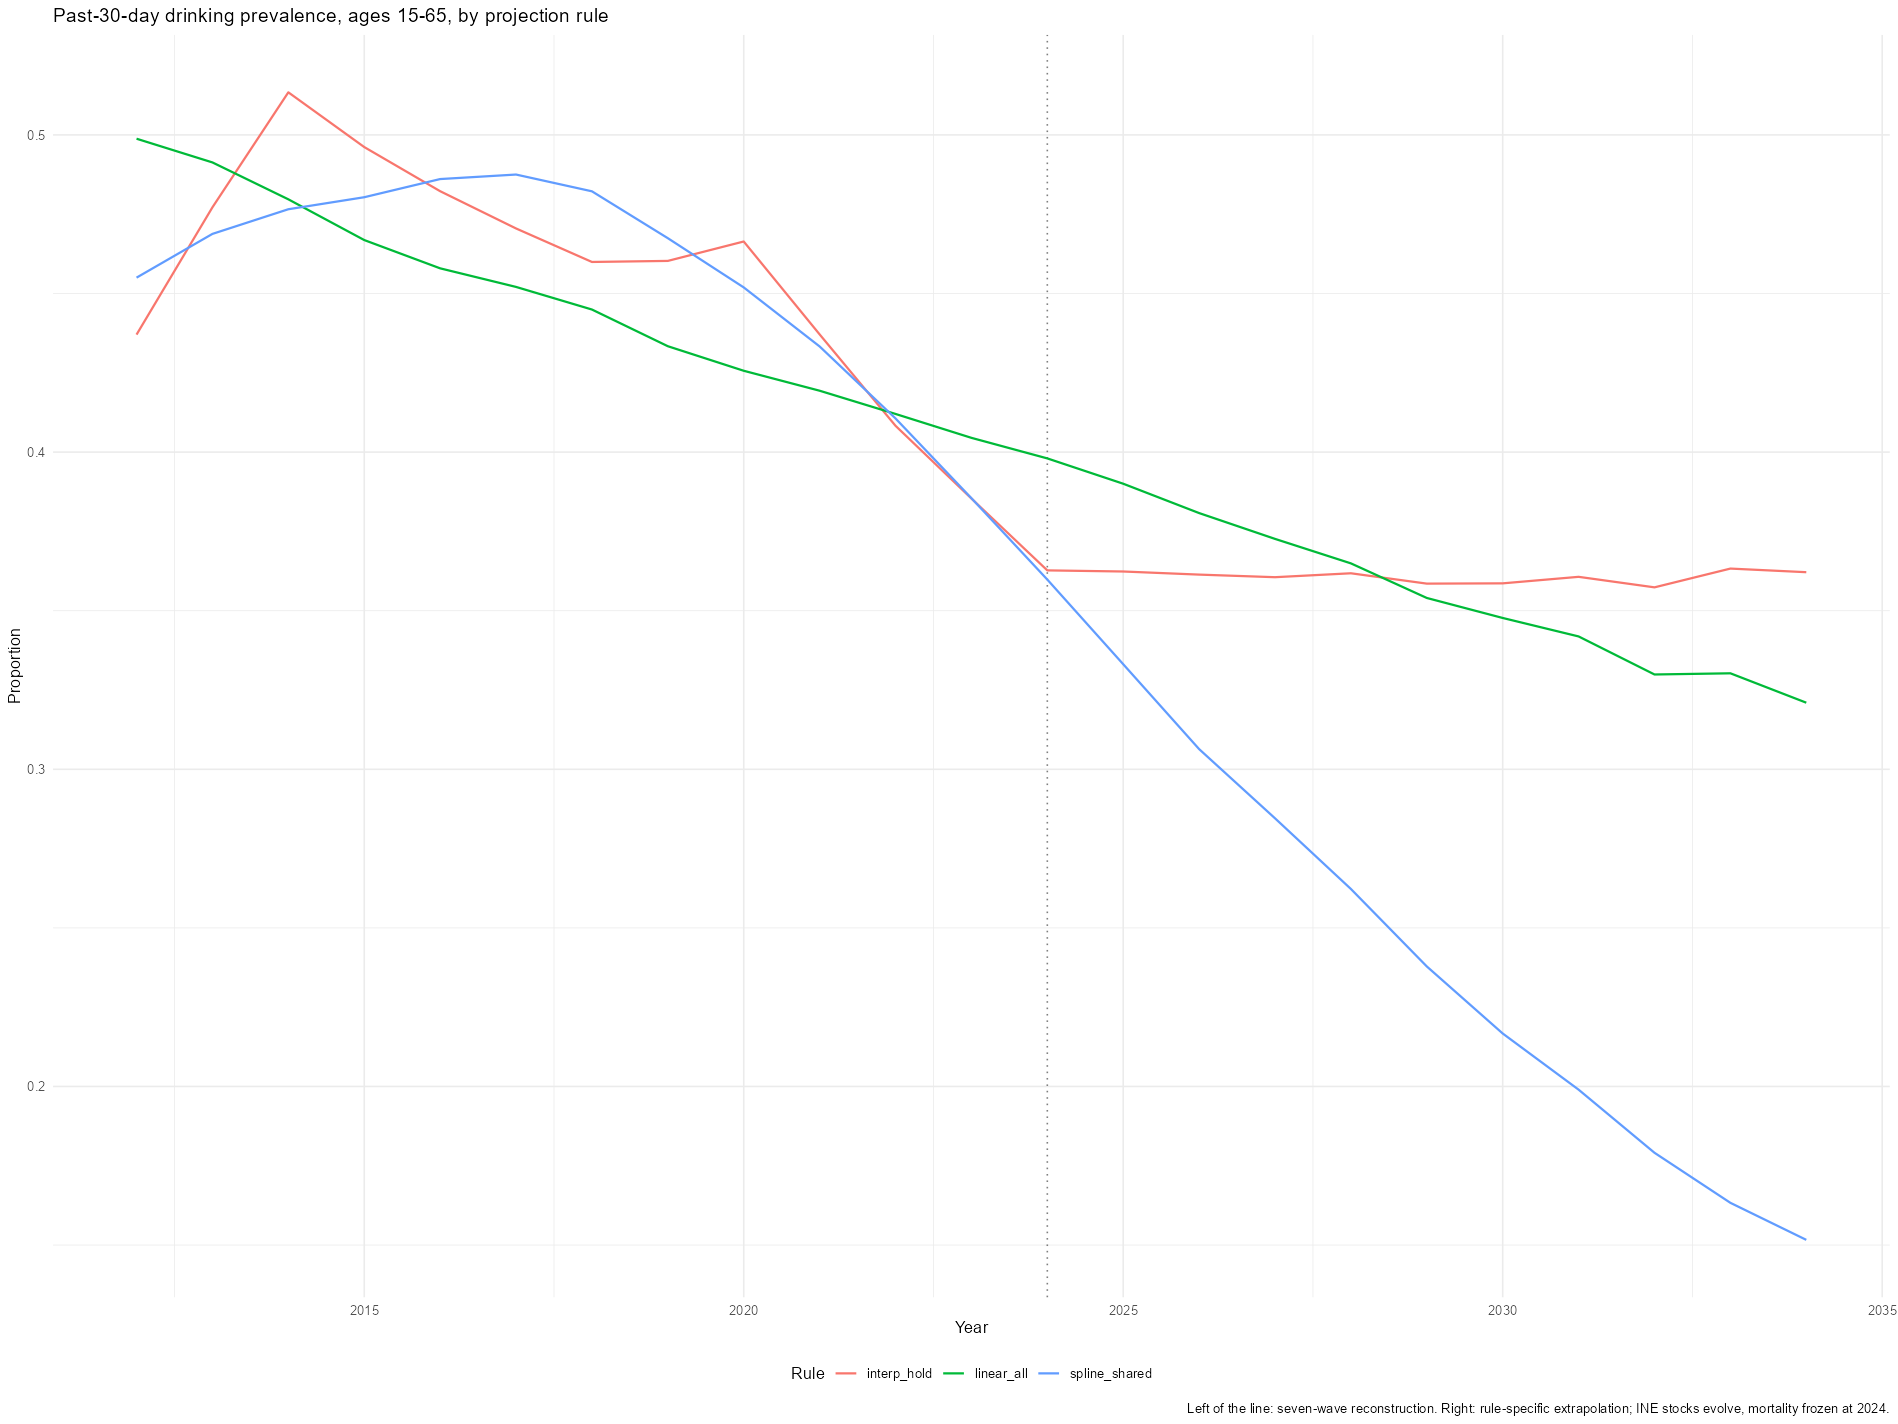

In [22]:
#| label: ms-projection-rules
.t0 <- Sys.time()
ms_projection_specs <- base::c("interp_hold", "linear_all", "spline_shared")
ms_projection_runs <- base::lapply(ms_projection_specs, function(spec)
  ms_simulate(ms_fit(ms_cfg$observed_end, spec), ms_cfg$start_year:ms_cfg$end_year,
    ms_cfg$n_sim, ms_cfg$seeds[1], ms_cfg$rho))
base::names(ms_projection_runs) <- ms_projection_specs
ms_projection <- dplyr::bind_rows(base::lapply(ms_projection_specs, function(spec) {
  run <- ms_projection_runs[[spec]]
  run$summary |>
    dplyr::group_by(year) |>
    dplyr::summarise(current_prevalence = stats::weighted.mean(current_mean, population),
      gpd_current = stats::weighted.mean(gpd_mean, current_mean * population),
      gpd_population = stats::weighted.mean(gpd_population, population),
      population = base::sum(population), .groups = "drop") |>
    dplyr::left_join(run$deaths |>
      dplyr::group_by(year) |>
      dplyr::summarise(expected_deaths = base::sum(expected_deaths), realized_deaths = base::sum(deaths),
        .groups = "drop"), by = "year") |>
    dplyr::mutate(spec = spec, period = base::ifelse(year <= 2024, "Historical", "Conditional projection"))
}))
base::stopifnot(base::nrow(ms_projection) == 23L * 3L, !base::anyNA(ms_projection))
ms_projection_2034 <- ms_projection |>
  dplyr::filter(year %in% base::c(2024L, 2029L, 2034L)) |>
  dplyr::select(spec, year, current_prevalence, gpd_current, gpd_population, expected_deaths)
ms_table(ms_projection_2034, "National 15-65 prevalence, intensity and expected all-cause deaths by projection rule")
ms_fig_projection <- ggplot2::ggplot(ms_projection, ggplot2::aes(year, current_prevalence, colour = spec)) +
  ggplot2::geom_vline(xintercept = 2024, linetype = 3, colour = "grey50") +
  ggplot2::geom_line(linewidth = 0.7) +
  ggplot2::labs(title = "Past-30-day drinking prevalence, ages 15-65, by projection rule",
    x = "Year", y = "Proportion", colour = "Rule",
    caption = "Left of the line: seven-wave reconstruction. Right: rule-specific extrapolation; INE stocks evolve, mortality frozen at 2024.") +
  ggplot2::theme_minimal(base_size = 11) + ggplot2::theme(legend.position = "bottom")
base::print(ms_fig_projection)
ms_table(ms_projection_runs$interp_hold$flows, "Person accounting for the interp_hold projection run")
base::message(base::sprintf("ms-projection-rules elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


Projecting 2025–2034 under three explicit rules shows how much the outcome depends on the assumption about drinking after the last survey wave, not on the engine. Holding 2024 fixed keeps national past-30-day prevalence at about 36–37% in 2034; extrapolating each cell's 2012–2024 trend lowers it to about 32%; extending the shared spline linearly lowers it to about 15%, a ten-year extrapolation of the post-2020 slope that is not credible. Expected all-cause deaths are identical across rules because mortality is frozen at 2024 and does not yet depend on alcohol exposure. The spread between rules is therefore a structural range of assumptions, not a confidence interval or a forecast. We present interp_hold as the central conditional scenario and the linear trend as a bounded alternative.

## 15. Parameter registry, provenance and aggregate exports

Regression specifications export coefficients; `interp_hold` exports its knots (cell × wave × logit prevalence × log intensity). Structural assumptions and input hashes are recorded. Exports are aggregate only; survey microdata and the baseline outputs are unchanged.


In [23]:
#| label: ms-export-parameters-and-audits
.t0 <- Sys.time()
ms_coefficients <- function(model, fit_name) {
  curve_rows <- dplyr::bind_rows(base::lapply(base::c("prevalence", "amount"), function(component) {
    f <- model[[component]]$fit
    if (base::inherits(f, "lm")) base::data.frame(fit = fit_name, component = component,
      parameter = base::names(stats::coef(f)), value = base::unname(stats::coef(f))) else
      dplyr::bind_rows(base::lapply(base::names(f), function(cl) base::data.frame(fit = fit_name,
        component = component, parameter = base::paste0("knot:", cl, ":", ms_cfg$start_year + 10 * f[[cl]]$time),
        value = f[[cl]][[2L]])))
  }))
  dplyr::bind_rows(curve_rows,
    base::data.frame(fit = fit_name, component = "hed", parameter = base::names(stats::coef(model$hed)),
      value = base::unname(stats::coef(model$hed))),
    base::data.frame(fit = fit_name, component = "all_cause_mortality",
      parameter = base::names(model$mortality_scale), value = base::unname(model$mortality_scale))) |>
    dplyr::mutate(spec = model$spec, last_fit_year = model$last_year, drop_2020 = model$drop_2020)
}
ms_parameters <- dplyr::bind_rows(
  base::lapply(ms_cfg$specs, function(s) ms_coefficients(ms_train_models[[s]], base::paste0("train2020_", s))),
  ms_coefficients(ms_reconstruction_model, "reconstruction2024_interp_hold"),
  base::lapply(base::setdiff(ms_projection_specs, "interp_hold"), function(s)
    ms_coefficients(ms_fit(ms_cfg$observed_end, s), base::paste0("refit2024_", s))))
ms_structural_parameters <- base::data.frame(parameter = base::c("rho", "minimum_age", "maximum_age", "n_sim",
  "replicates", "first_seed", "grams_per_drink", "spline_df", "cutoffs", "reconstruction_spec"),
  value = base::c(ms_cfg$rho, 15, 65, ms_cfg$n_sim, base::length(ms_cfg$seeds), ms_cfg$seeds[1], 12, 2,
    base::paste(ms_cfg$cutoffs, collapse = "/"), "interp_hold"),
  interpretation = base::c("Unidentified persistence; sensitivity 0 and 0.95", "Entry at age 15",
    "Exit at age 66; older-age benefits excluded", "Synthetic population scale",
    "Monte Carlo repeats, not parameter uncertainty", "Seeds 2125-2129", "Inherited survey measurement convention",
    "Shared natural spline degrees of freedom", "Rolling-origin fit-through years",
    "Interpolates the seven waves and holds 2024 afterwards"))
ms_table(ms_structural_parameters, "Structural assumptions to discuss with coauthors")
ms_all_sources <- base::unique(base::c(ms_exposure_files, ms_demography_files,
  "__andres_control/microsim_base_ACC_2012_2024.ipynb"))
ms_provenance <- base::data.frame(file = ms_all_sources,
  md5 = base::unname(tools::md5sum(ms_path(ms_all_sources))))
# SIMAH is cited by DOI (not vendored): its own row, without a file hash.
ms_provenance <- base::rbind(ms_provenance, base::data.frame(
  file = "SIMAH release 0.1.1, doi:10.5281/zenodo.15641639", md5 = NA_character_))
if (ms_cfg$export) {
  base::dir.create(here::here(ms_cfg$output_dir), recursive = TRUE, showWarnings = FALSE)
  ms_exports <- base::list(observed_targets = ms_targets, data_audit = ms_data_audit, wave_comparability_audit = ms_wave_audit,
    rolling_origin_comparison = ms_rolling, rolling_origin_metrics = ms_rolling_metrics,
    rolling_origin_by_cutoff = ms_rolling_by_cutoff, sensitivity_2020 = ms_sens_2020,
    holdout2020_by_spec_metrics = ms_holdout_metrics, holdout2020_by_spec_comparison = ms_holdout_long,
    driver_identity_check = ms_driver_identity,
    reconstruction_metrics = ms_reconstruction_metrics, reconstruction_comparison = ms_reconstruction_long,
    mortality_concordance = ms_mortality_comparison, persistence_sensitivity = ms_sensitivity,
    projection_rules = ms_projection,
    projection_mortality_interp_hold = ms_projection_runs$interp_hold$deaths,
    demographic_accounting = ms_projection_runs$interp_hold$flows,
    model_parameters = ms_parameters, structural_parameters = ms_structural_parameters,
    input_provenance = ms_provenance)
  for (name in base::names(ms_exports))
    utils::write.csv(ms_exports[[name]], here::here(ms_cfg$output_dir, base::paste0(name, ".csv")),
      row.names = FALSE, fileEncoding = "UTF-8")
  ggplot2::ggsave(here::here(ms_cfg$output_dir, "rolling_origin_prevalence.png"), ms_fig_rolling, width = 8, height = 5, dpi = 160)
  ggplot2::ggsave(here::here(ms_cfg$output_dir, "reconstruction_prevalence.png"), ms_fig_recon_prevalence, width = 9, height = 8, dpi = 160)
  ggplot2::ggsave(here::here(ms_cfg$output_dir, "reconstruction_intensity.png"), ms_fig_recon_intensity, width = 9, height = 8, dpi = 160)
  ggplot2::ggsave(here::here(ms_cfg$output_dir, "projection_rules.png"), ms_fig_projection, width = 8, height = 5, dpi = 160)
  base::cat("Aggregate outputs saved to ", ms_cfg$output_dir, ". No survey microdata exported.\n", sep = "")
}
base::print(utils::sessionInfo())
base::message(base::sprintf("ms-export-parameters-and-audits elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))




Table: Structural assumptions to discuss with coauthors

|parameter           |value               |interpretation                                         |
|:-------------------|:-------------------|:------------------------------------------------------|
|rho                 |0.8                 |Unidentified persistence; sensitivity 0 and 0.95       |
|minimum_age         |15                  |Entry at age 15                                        |
|maximum_age         |65                  |Exit at age 66; older-age benefits excluded            |
|n_sim               |25000               |Synthetic population scale                             |
|replicates          |5                   |Monte Carlo repeats, not parameter uncertainty         |
|first_seed          |2125                |Seeds 2125-2129                                        |
|grams_per_drink     |12                  |Inherited survey measurement convention                |
|spline_df           |2                  

## 16. Interpretation

**Code verification.** Repeatability, stock identities, exposure identities, irreversible histories, exact reproduction of training targets by `interp_hold`, and the no-leakage perturbation for four specifications × four cutoffs all pass. The driver-identity check confirms that engine cell prevalences reproduce the driver curves within binomial Monte Carlo noise (largest |z| 3.3 over 224 cells). Passing these says the code does what the equations say; it says nothing about whether the equations are right.

**Survey comparability.** The computable signals single out **2022**: weight coefficient of variation 1.05 against 1.58–1.91 in every other wave, effective-sample ratio 0.47 against 0.22–0.29, and a weighted 15–65 population at 91% of the INE June stock against 77–80% elsewhere. Either the 2022 weights were calibrated differently or the design differs; the files do not say which. Until the SENDA reports are checked, the 2022 estimate is not on the same footing as its neighbours, and the size of the 2022 step should not be read as measured with the same instrument. 2018 has the highest unknown-status (1.8%) and missing-intensity (10.1%) shares. Age × sex composition gaps against INE stay within 3 points in all waves.

**Rolling-origin evaluation (driver level).** One wave ahead, averaged over the four cutoffs: shared spline 4.5 points, hold-last 4.9, static-2012 5.4, per-cell linear trend 6.7. The spline wins on average but has the worst single miss (6.9 points predicting 2020, because it extrapolated the 2016–2018 dip and 2020 rebounded); hold-last is the most stable (3.2–6.7 across cutoffs); the linear trend is worst at every cutoff. Two waves ahead, nothing beats static-2012 (5.9 points): prevalence in 2022/2024 returned to roughly its 2012 level, so at a four-year horizon “nothing changed since 2012” outperforms every dynamic rule.  Working-interval coverage (survey sampling error only; 2020 targets have no interval, so 24 of 32 one-wave cells) never exceeds 79%, i.e. errors exceed sampling noise.

**The 2022 decline and the 2020 wave.** From data through 2020, only the shared spline comes close to 2022 (3.3 points, bias +1.9) because the shared curve already bends down after 2014; hold-last is biased +6.3 and the linear trend +7.3. Dropping the 2020 wave reverses that: the spline error rises to 6.3 points with the bias flipping to −5.7, while hold-last is essentially unchanged (6.7 → 6.9). The one rule that “predicted” the decline depends on the 2020 point to do so. That is the sensitivity Codex asked for, and it argues against presenting the spline as having anticipated 2022.

**Engine confirmation at the 2020 cutoff (16 cells, five seeds).** Prevalence RMSE: spline 3.9 points (bias +3.1), static-2012 6.8, hold-last 9.3, linear trend 10.4 (bias +9.9), which reproduces the baseline's 10.26 under new seeds. Intensity: hold-last is best (0.60 g/day); HED 5.1–6.6 points with negative bias for every specification. Ranking by intensity and by prevalence differ, so “best rule” is outcome-specific.

**Reconstruction 2012–2024.** With all seven waves, the engine reproduces prevalence to 0.5 points RMSE (Monte Carlo SD 0.9), intensity to 0.11 g/day, with full working-interval coverage—at noise level, as it must be for calibration inputs. HED is underpredicted by 4.5 points (RMSE 6.4, coverage 65%) because the conditional HED model is not calibrated to a margin; this is the next calibration item, ahead of any RR integration that uses HED. All-cause multipliers are 0.970 (women) and 0.945 (men); the relative error of expected deaths drifts from −3.1% (men, 2012) to +3.8% (men, 2024), so a single multiplier averages an HMD–DEIS drift over the period. A year-specific multiplier would remove that pattern by construction and should be labelled as calibration if adopted.

**All-cause mortality in 2020–2022.** The age-standardized rate (WHO World Standard Population restricted to ages 15–64 [@paho2009agestandardized]) rises 13.5% (men) and 11.4% (women) in 2020 over 2019, peaks in 2021 (+26.3%, +19.9%) and is back at the 2019 level in 2023. Excess deaths at ages 15–65 in 2020–2022 over the 2019 level are 16,401 (2019 rate applied to each year's population) or 17,994 (2019 count). Deaths coded U07.1/U07.2 number 14,208, 79–87% of that excess (2020: 105%, 2021: 82%, 2022: 48% of the count-based excess); this is a descriptive decomposition, not proof that the remainder is indirect. A year-specific national life table lowers remaining life expectancy in exactly these years (HMD, men: e(50) −6.4% from 2019 to 2021), so YLL per death falls while deaths rise [@devleesschauwer2020yll]; a fixed 2019 table is the planned sensitivity. The choice of standard population is arbitrary and is declared here [@haneef2021bod]. Mortality selection cannot explain the 2022/2024 prevalence decline: even if all ≈18,000 excess deaths were drinkers, prevalence would fall by about 0.07 points.

**Persistence.** With the margins fixed by calibration, rho = 0/0.8/0.95 still yields 1.7%/6.1%/12.6% synthetic never-drinkers in 2024 at the same 36–37% current prevalence. Unchanged conclusion: rho is unidentified and must not be used to repair a marginal fit.

**Projection 2025–2034.** National 15–65 prevalence in 2034: 36.6% (hold-last), 32.2% (linear trend), 15.2% (shared spline). The spline's linear extrapolation of the post-2020 slope over ten years is not credible and shows why a rule that wins one wave ahead cannot be run unmodified for a decade. Expected all-cause deaths are identical across rules (35,693 in 2034) because survival does not yet depend on exposure; that equality is the reminder that the mortality link is still absent.

**Proposed decisions for ACC and coauthors.** (1) Deliver the seven-wave `interp_hold` reconstruction as the 2012–2024 base: complete, reproducible, with transition assumptions stated. (2) For 2025 onward, present hold-last as the central conditional scenario and the linear trend as a bounded alternative; do not use the spline beyond one wave. (3) Treat the 2022 weighting profile as an open comparability question before attributing the 2022/2024 decline to behaviour. (4) Calibrate an HED margin and decide on year-specific mortality multipliers before RR integration. (5) None of the waves is an untouched holdout any longer; future claims of predictive performance need a new wave or an independent survey.


## 17. Additional information that would change what can be claimed

| Information | What it would allow | Status in the project |
| :--- | :--- | :--- |
| Longitudinal follow-up of the same people | Estimate initiation, cessation, relapse and persistence; identify rho instead of assuming it | Not available; no Chilean alcohol panel identified |
| Retrospective history (age at first drink, time since last drink) | Constrain plausible never/former trajectories, subject to recall error | Partially present in ENPG items; not yet harmonized or used |
| Independent surveys with comparable definitions | External contrast of prevalence and intensity outside the calibration data | To be reviewed (e.g., ENS/CASEN items); definitions differ |
| Sales / APC and beverage-specific consumption | Contrast total volume and beverage mix; requires age, coverage and denominator harmonization | APC series exist; the survey-to-APC bridge is unresolved (baseline, Section 4) |
| Cause-specific mortality with matching RR | Build and evaluate the exposure → survival link | DEIS causes and RR objects exist in the AAF/PIF modules; not linked to the engine |
| SENDA methodological reports by wave | Attribute or rule out measurement change in 2020–2024 | Requested items listed in Section 6 |

Further cross-sectional waves improve marginal trends but do not identify who starts or stops drinking; APC informs total volume but does not pin down prevalence or transitions. The defensible commitment remains a well-calibrated 2012–2024 reconstruction with explicit transition assumptions, and a projection whose rule is chosen by the temporal evaluation above and labelled as conditional.


## References
 